# Publication Figures: Transit Accessibility and Social Mixing at POIs

**Section 1: Residential, Visitor, and Transit Catchment Social Mixing**
- Figure 1: Overview comparison (3 Sweden + 3 US cities) and  Error bar plots (10 Sweden + 3 US cities)
- Table 1: Spatial clustering (Moran's I + LISA summary)
- Appendix: Basic statistics and statistical test results

**Section 2: Transit Catchment Effects (OLS and SLM)**
- Figure 2: Coefficient comparison with uncertainty
- Table 2: Model coverage and performance summary
- Appendix: Full regression results

**Section 3A: GWR-Based Spatial Heterogeneity**
- Figure 3: GWR coefficient maps
- Appendix: GWR summary statistics

**Section 3B: Category-Level Analysis**
- Figure 4a: Hotspot rate by POI category

**Section 3C: Understanding Hotspots**
- Figure 4b...: What distinguishes hotspots (catchment diversity, transit connectivity)
- Table 3: Hotspot logistic regression results


In [18]:
%cd /workspace

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import geopandas as gpd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Output directories
FIG_DIR = Path('outputs/figures')
TABLE_DIR = Path('outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures: {FIG_DIR}")
print(f"Tables: {TABLE_DIR}")

/workspace
Figures: outputs/figures
Tables: outputs/tables


## Visual Style & City Configuration

In [2]:
def setup_mpl():
    """Setup matplotlib for publication-quality figures."""
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "xtick.top": False,
        "ytick.right": False,
        "axes.labelpad": 2,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

setup_mpl()

# Color palette
COLORS = {
    'US': '#A85456',
    'Sweden': '#5eaad9',
    'birth': '#3C5488',
    'income': '#F39B7F',
    'residential': '#7E6148',
    'visitor': '#00A087',
    'catchment': '#8491B4',
    'positive': '#00A087',
    'negative': '#DC0000',
    'nonsig': '#868686',
}

def mm_to_inch(mm):
    return mm / 25.4

# Figure sizes
FIG_SMALL = (mm_to_inch(60), mm_to_inch(60))
FIG_WIDE = (mm_to_inch(150), mm_to_inch(60))
FIG_TALL = (mm_to_inch(80), mm_to_inch(120))
FIG_LARGE = (mm_to_inch(150), mm_to_inch(100))
FIG_FULL = (mm_to_inch(180), mm_to_inch(120))

def save_figure(fig, name, formats=['pdf', 'png']):
    for fmt in formats:
        path = FIG_DIR / f"{name}.{fmt}"
        dpi = 600 if fmt == 'pdf' else 300
        fig.savefig(path, format=fmt, dpi=dpi, facecolor='white', bbox_inches='tight')
        print(f"Saved: {path}")

print("Style loaded.")

from matplotlib.colors import LinearSegmentedColormap

def red_gray_blue():
    return LinearSegmentedColormap.from_list(
        "RedGrayBlue",
        [
            (0.0, "#b2182b"),   # blue (negative)
            (0.5, "#bdbdbd"),   # gray (zero)
            (1.0, "#2166ac"),   # red (positive)
        ]
    )

Style loaded.


In [3]:
# =============================================================================
# CITY CONFIGURATION
# =============================================================================

# City display names (standardized)
CITY_DISPLAY = {
    # US cities
    'new_york': 'New York',
    'washington_dc': 'Washington DC',
    'atlanta': 'Atlanta',
    # Sweden cities
    'Stockholm': 'Stockholm',
    'Göteborg': 'Gothenburg',
    'Malmö': 'Malmö',
    'Uppsala': 'Uppsala',
    'Linköping': 'Linköping',
    'Västerås': 'Västerås',
    'Örebro': 'Örebro',
    'Helsingborg': 'Helsingborg',
    'Norrköping': 'Norrköping',
    'Jonköping': 'Jonköping',
    'Lund': 'Lund',
}

# City bounding boxes for consistent map extents [lat_min, lat_max, lon_min, lon_max]
CITY_BOUNDS = {
    # Sweden
    'Stockholm': [59.20, 59.45, 17.70, 18.30],
    'Göteborg': [57.60, 57.80, 11.85, 12.10],
    'Malmö': [55.50, 55.65, 12.90, 13.10],
    'Uppsala': [59.78, 59.92, 17.55, 17.75],
    'Linköping': [58.35, 58.45, 15.55, 15.70],
    'Västerås': [59.55, 59.68, 16.45, 16.65],
    'Örebro': [59.22, 59.32, 15.15, 15.30],
    'Helsingborg': [56.00, 56.10, 12.65, 12.80],
    'Norrköping': [58.55, 58.65, 16.10, 16.25],
    'Jonköping': [57.75, 57.82, 14.12, 14.22],
    # US
    'new_york': [40.50, 40.95, -74.30, -73.65],
    'washington_dc': [38.0, 39.75, -78.75, -76.25],
    'atlanta': [32.75, 34.75, -85.25, -83],
}

# Top cities for analysis (ranked by N POIs)
TOP_3_SWEDEN = ['Stockholm', 'Göteborg', 'Malmö']
TOP_10_SWEDEN = ['Stockholm', 'Göteborg', 'Malmö', 'Uppsala', 'Linköping', 
                 'Västerås', 'Örebro', 'Helsingborg', 'Norrköping', 'Jonköping']
US_CITIES = ['new_york', 'washington_dc', 'atlanta']

print(f"Top 3 Sweden: {TOP_3_SWEDEN}")
print(f"US cities: {US_CITIES}")

Top 3 Sweden: ['Stockholm', 'Göteborg', 'Malmö']
US cities: ['new_york', 'washington_dc', 'atlanta']


## Load All Data

In [81]:
# Load POI diversity metrics
us_pois = pd.read_parquet('dbs/routing/us_poi_diversity_metrics.parquet')
sweden_pois = pd.read_parquet('dbs/routing/sweden_poi_diversity_metrics.parquet')

us_pois['country'] = 'US'
sweden_pois['country'] = 'Sweden'

all_pois = pd.concat([us_pois, sweden_pois], ignore_index=True)
print(f"Total POIs: {len(all_pois):,}")

# Phase 2: Spatial analysis
spillover_birth = pd.read_csv('outputs/phase2/spatial_spillover_results_birth.csv')
spillover_income = pd.read_csv('outputs/phase2/spatial_spillover_results_income.csv')
lisa_summary = pd.read_csv('outputs/phase2/lisa_summary.csv')

# Phase 3: GWR
gwr_df = pd.read_csv('outputs/phase3/gwr_summary_results.csv')
gwr_df = gwr_df[gwr_df['success'] == True].copy()
gwr_df['country'] = gwr_df['city'].apply(lambda x: 'US' if 'US' in x else 'Sweden')
print(f"GWR results: {len(gwr_df)} successful runs")

# Load local coefficients
coef_dir = Path('outputs/phase3/gwr_local_coefficients')
coef_files = list(coef_dir.glob('*.parquet'))
all_coefs = [pd.read_parquet(f) for f in coef_files]
coef_df = pd.concat(all_coefs, ignore_index=True)
coef_df['country'] = coef_df['city'].apply(lambda x: 'US' if 'US' in x else 'Sweden')
print(f"Local coefficients: {len(coef_df):,} POIs")

Total POIs: 609,571
GWR results: 140 successful runs
Local coefficients: 1,134,516 POIs


---
# SECTION 1: Residential, Empirical, and Transit Catchment Social Mixing

Comparing three types of social mixing:
- **Residential**: Diversity of the POI's home tract
- **Empirical (Visitor)**: Actual diversity of visitors
- **Transit Catchment**: Diversity of areas reachable by transit

In [5]:
# Prepare data for Section 1
# Compute city-level statistics

def compute_city_stats(df, city_col='city'):
    """Compute mean and std for mixing metrics by city."""
    stats = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = city_df['country'].iloc[0]
        
        row = {
            'city': city,
            'country': country,
            'n_pois': len(city_df),
            # Birth dimension
            'residential_birth_mean': city_df['residential_entropy_birth_norm'].mean(),
            'residential_birth_std': city_df['residential_entropy_birth_norm'].std(),
            'visitor_birth_mean': city_df['visitor_entropy_birth_norm'].mean(),
            'visitor_birth_std': city_df['visitor_entropy_birth_norm'].std(),
            'catchment_birth_mean': city_df['catchment_entropy_birth_norm'].mean(),
            'catchment_birth_std': city_df['catchment_entropy_birth_norm'].std(),
            # Income dimension
            'residential_income_mean': city_df['residential_entropy_income_norm'].mean(),
            'residential_income_std': city_df['residential_entropy_income_norm'].std(),
            'visitor_income_mean': city_df['visitor_entropy_income_norm'].mean(),
            'visitor_income_std': city_df['visitor_entropy_income_norm'].std(),
            'catchment_income_mean': city_df['catchment_entropy_income_norm'].mean(),
            'catchment_income_std': city_df['catchment_entropy_income_norm'].std(),
        }
        stats.append(row)
    
    return pd.DataFrame(stats)

city_stats = compute_city_stats(all_pois)
city_stats = city_stats.sort_values('n_pois', ascending=False)
print(f"City statistics computed for {len(city_stats)} cities")
print(city_stats[['city', 'country', 'n_pois']].head(15))

City statistics computed for 21 cities
             city country  n_pois
0        new_york      US  290270
2         atlanta      US  102181
1   washington_dc      US   84650
4       Stockholm  Sweden   35948
19       Göteborg  Sweden   16806
16          Malmö  Sweden   12680
14        Uppsala  Sweden    8170
12       Västerås  Sweden    5666
8          Örebro  Sweden    5657
6       Linköping  Sweden    5634
7     Helsingborg  Sweden    5488
3            Lund  Sweden    4900
9      Norrköping  Sweden    4652
11       Karlstad  Sweden    3902
20       Halmstad  Sweden    3816


In [6]:
# Figure 1: Overview Comparison (Top 10 Sweden + 3 US)
# Panels a,b: Bar charts; Panels c,d: Bivariate spatial maps

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def create_bivariate_colormap():
    """Create a 3x3 bivariate colormap (visitor on y-axis, other on x-axis)."""
    # Stevens' bivariate color scheme
    # Rows: visitor (low to high, bottom to top)
    # Cols: residential/catchment (low to high, left to right)
    colors = [
        # Low visitor
        ['#e8e8e8', '#b5c0da', '#6c83b5'],  # low, med, high other
        # Med visitor  
        ['#b8d6be', '#90b2b3', '#567994'],
        # High visitor
        ['#73ae80', '#5a9178', '#2a5a5b'],
    ]
    return colors

def assign_bivariate_class(x_vals, y_vals):
    """Assign bivariate class (0-8) based on terciles."""
    # Compute terciles
    x_terciles = np.nanpercentile(x_vals, [33.33, 66.67])
    y_terciles = np.nanpercentile(y_vals, [33.33, 66.67])
    
    # Classify
    x_class = np.zeros(len(x_vals), dtype=int)
    x_class[x_vals > x_terciles[0]] = 1
    x_class[x_vals > x_terciles[1]] = 2
    
    y_class = np.zeros(len(y_vals), dtype=int)
    y_class[y_vals > y_terciles[0]] = 1
    y_class[y_vals > y_terciles[1]] = 2
    
    return x_class, y_class

def plot_bivariate_map(ax, df, x_col, y_col, bounds=None):
    """Plot bivariate map for a single city without basemap."""

    colors_matrix = create_bivariate_colormap()

    valid = df[[x_col, y_col, "geometry"]].dropna().copy()
    valid = valid[valid.geometry.notnull()]

    # bounds must be (xmin, xmax, ymin, ymax) in EPSG:3857
    if bounds is not None:
        xmin, xmax, ymin, ymax = bounds
        valid = valid.cx[xmin:xmax, ymin:ymax]

    if len(valid) < 10:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return

    x_class, y_class = assign_bivariate_class(
        valid[x_col].values,
        valid[y_col].values
    )

    point_colors = [colors_matrix[y][x] for x, y in zip(x_class, y_class)]

    ax.scatter(
        valid.geometry.x.values,
        valid.geometry.y.values,
        c=point_colors,
        s=0.8,
        alpha=0.7,
        rasterized=True,
        linewidths=0
    )

    if bounds is not None:
        ax.set_xlim(bounds[0], bounds[1])
        ax.set_ylim(bounds[2], bounds[3])

    ax.set_aspect("equal", "box")
    ax.axis("off")

def create_bivariate_legend(ax, x_label, y_label):
    """Create a bivariate legend."""
    colors_matrix = create_bivariate_colormap()
    
    # Draw 3x3 grid
    for i in range(3):  # y (visitor)
        for j in range(3):  # x (other)
            rect = mpatches.Rectangle((j/3, i/3), 1/3, 1/3, 
                                       facecolor=colors_matrix[i][j], edgecolor='white', linewidth=0.5)
            ax.add_patch(rect)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0.167, 0.5, 0.833])
    ax.set_xticklabels(['Low', 'Med', 'High'], fontsize=5)
    ax.set_yticks([0.167, 0.5, 0.833])
    ax.set_yticklabels(['Low', 'Med', 'High'], fontsize=5)
    ax.set_xlabel(x_label, fontsize=6)
    ax.set_ylabel(y_label, fontsize=6)
    ax.set_aspect('equal')

# Select cities (Top 10 Sweden + 3 US for comprehensive analysis)
selected_cities = TOP_10_SWEDEN + US_CITIES
city_display_names = [CITY_DISPLAY.get(c, c) for c in selected_cities]

print("Creating Figure 1 with bivariate spatial maps...")
print(f"Cities: {city_display_names}")

Creating Figure 1 with bivariate spatial maps...
Cities: ['Stockholm', 'Gothenburg', 'Malmö', 'Uppsala', 'Linköping', 'Västerås', 'Örebro', 'Helsingborg', 'Norrköping', 'Jonköping', 'New York', 'Washington DC', 'Atlanta']


## Figure 1-0: Transit Catchment Data Coverage

Before analyzing diversity patterns, we examine the coverage of transit catchment data across cities.

In [31]:
# =============================================================================
# Figure 1-0: Transit Catchment Coverage by City
# =============================================================================

def compute_catchment_coverage(df, city_col='city'):
    """Compute share of POIs with non-null transit catchment by city."""
    coverage = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = 'US' if city in US_CITIES else 'Sweden'
        
        n_total = len(city_df)
        n_with_birth = city_df['catchment_entropy_birth_norm'].notna().sum()
        n_with_income = city_df['catchment_entropy_income_norm'].notna().sum()
        
        coverage.append({
            'city': city,
            'country': country,
            'n_total': n_total,
            'n_with_catchment_birth': n_with_birth,
            'n_with_catchment_income': n_with_income,
            'pct_with_catchment_birth': 100 * n_with_birth / n_total if n_total > 0 else 0,
            'pct_with_catchment_income': 100 * n_with_income / n_total if n_total > 0 else 0,
        })
    
    return pd.DataFrame(coverage)

coverage_df = compute_catchment_coverage(all_pois)

In [32]:
selected_cities = ['Stockholm', 'Göteborg', 'Malmö',
                   'new_york', 'washington_dc', 'atlanta']

In [ ]:
# Plot coverage (compact single-series version)
fig, ax = plt.subplots(figsize=(mm_to_inch(30), mm_to_inch(60)))

plot_cov = coverage_df[coverage_df['city'].isin(selected_cities)].copy()
plot_cov['display_city'] = plot_cov['city'].map(CITY_DISPLAY)

city_order = {c: i for i, c in enumerate(selected_cities)}
plot_cov = plot_cov.sort_values('city', key=lambda x: x.map(city_order))

x = np.arange(len(plot_cov))

# Use one coverage column only
bars = ax.bar(
    x,
    plot_cov['pct_with_catchment_birth'],
    width=0.6,
    color=COLORS['catchment'],
    alpha=0.85
)

# Compact formatting
ax.set_ylabel('POIs w/ transit catchment (%)')
ax.set_xticks(x)
ax.set_xticklabels(plot_cov['display_city'], rotation=90)
ax.tick_params(axis='y')
ax.set_ylim(0, 105)

# Light reference lines
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.4, alpha=0.7)

# Clean up without seaborn
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(left=0.28, right=0.98, bottom=0.28, top=0.98)

fig.savefig(
    'outputs/figures/fig1_0_catchment_coverage.pdf',
    dpi=600,
    facecolor="white"
)
plt.show()

# Save coverage table
coverage_df.to_csv(TABLE_DIR / 'catchment_coverage.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'catchment_coverage.csv'}")

print("\nCatchment Coverage Summary:")
print(
    coverage_df[coverage_df['city'].isin(selected_cities)][
        ['city', 'n_total', 'pct_with_catchment_birth']
    ].rename(columns={'pct_with_catchment_birth': 'pct_with_catchment'}).to_string(index=False)
)

## Figure 1a-b: Bar Charts by Catchment Regime (2x2 Layout)

Separate analysis for POIs with and without transit catchment data.

In [34]:
# =============================================================================
# Compute Statistics by Regime (With/Without Catchment)
# =============================================================================

def compute_city_stats_by_regime(df, city_col='city'):
    """Compute mean and std for mixing metrics by city, split by catchment availability."""
    stats = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = 'US' if city in US_CITIES else 'Sweden'
        
        for dim in ['birth', 'income']:
            res_col = f'residential_entropy_{dim}_norm'
            vis_col = f'visitor_entropy_{dim}_norm'
            cat_col = f'catchment_entropy_{dim}_norm'
            
            # Split by catchment availability
            has_catchment = city_df[cat_col].notna()
            df_with = city_df[has_catchment]
            df_without = city_df[~has_catchment]
            
            # With catchment
            if len(df_with) > 0:
                stats.append({
                    'city': city,
                    'country': country,
                    'dimension': dim,
                    'regime': 'with_catchment',
                    'n_pois': len(df_with),
                    'residential_mean': df_with[res_col].mean(),
                    'residential_std': df_with[res_col].std(),
                    'visitor_mean': df_with[vis_col].mean(),
                    'visitor_std': df_with[vis_col].std(),
                    'catchment_mean': df_with[cat_col].mean(),
                    'catchment_std': df_with[cat_col].std(),
                })
            
            # Without catchment
            if len(df_without) > 0:
                stats.append({
                    'city': city,
                    'country': country,
                    'dimension': dim,
                    'regime': 'without_catchment',
                    'n_pois': len(df_without),
                    'residential_mean': df_without[res_col].mean(),
                    'residential_std': df_without[res_col].std(),
                    'visitor_mean': df_without[vis_col].mean(),
                    'visitor_std': df_without[vis_col].std(),
                    'catchment_mean': np.nan,
                    'catchment_std': np.nan,
                })
    
    return pd.DataFrame(stats)

stats_by_regime = compute_city_stats_by_regime(all_pois)
print(f"Statistics computed: {len(stats_by_regime)} rows")
print(stats_by_regime[stats_by_regime['city'].isin(selected_cities)].groupby(['regime', 'dimension']).size())

Statistics computed: 84 rows
regime             dimension
with_catchment     birth        6
                   income       6
without_catchment  birth        6
                   income       6
dtype: int64


In [ ]:
# =============================================================================
# Figure 1a-b: 1x2 Bar Charts — Birth Background Only
# =============================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(mm_to_inch(75), mm_to_inch(60)),
    sharey=True
)

cities = [CITY_DISPLAY.get(c, c) for c in selected_cities]
x = np.arange(len(cities))
width = 0.25

panels = [
    ('with_catchment', 'birth'),
    ('without_catchment', 'birth')
]

legend_handles = []
legend_labels = []

for idx, (regime, dim) in enumerate(panels):
    ax = axes[idx]

    plot_data = stats_by_regime[
        (stats_by_regime['regime'] == regime) &
        (stats_by_regime['dimension'] == dim) &
        (stats_by_regime['city'].isin(selected_cities))
    ].copy()

    plot_data['display_city'] = plot_data['city'].map(
        lambda c: CITY_DISPLAY.get(c, c)
    )

    city_order = {
        CITY_DISPLAY.get(c, c): i
        for i, c in enumerate(selected_cities)
    }

    plot_data = plot_data.sort_values(
        'display_city',
        key=lambda s: s.map(city_order)
    )

    # Fill missing cities to preserve consistent x-axis order
    missing_cities = [
        c for c in selected_cities
        if CITY_DISPLAY.get(c, c) not in plot_data['display_city'].values
    ]

    if missing_cities:
        missing_rows = pd.DataFrame([
            {
                'city': c,
                'display_city': CITY_DISPLAY.get(c, c),
                'dimension': dim,
                'regime': regime,
                'residential_mean': np.nan,
                'residential_std': np.nan,
                'visitor_mean': np.nan,
                'visitor_std': np.nan,
                'catchment_mean': np.nan,
                'catchment_std': np.nan
            }
            for c in missing_cities
        ])

        plot_data = pd.concat([plot_data, missing_rows], ignore_index=True)

        plot_data = plot_data.sort_values(
            'display_city',
            key=lambda s: s.map(city_order)
        )

    if regime == 'with_catchment':
        mtypes = ['residential', 'visitor', 'catchment']
        mlabels = ['Residential', 'Visitor', 'Transit catchment']
        mcolors = [
            COLORS['residential'],
            COLORS['visitor'],
            COLORS['catchment']
        ]

        for i, (mtype, label, color) in enumerate(zip(mtypes, mlabels, mcolors)):
            bars = ax.bar(
                x + (i - 1) * width,
                plot_data[f'{mtype}_mean'].values,
                width,
                yerr=plot_data[f'{mtype}_std'].values,
                color=color,
                capsize=2,
                error_kw={'linewidth': 0.5},
                label=label
            )

            if idx == 0:
                legend_handles.append(bars[0])
                legend_labels.append(label)

    else:
        mtypes = ['residential', 'visitor']
        mlabels = ['Residential', 'Visitor']
        mcolors = [
            COLORS['residential'],
            COLORS['visitor']
        ]
        width_2 = 0.30

        for i, (mtype, label, color) in enumerate(zip(mtypes, mlabels, mcolors)):
            ax.bar(
                x + (i - 0.5) * width_2,
                plot_data[f'{mtype}_mean'].values,
                width_2,
                yerr=plot_data[f'{mtype}_std'].values,
                color=color,
                capsize=2,
                error_kw={'linewidth': 0.5},
                label=label
            )

    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=30, ha='right')
    ax.set_ylim(0, 1.1)

    # Sweden / US separator
    ax.axvline(
        x=2.5,
        color='gray',
        linestyle='--',
        linewidth=0.5,
        alpha=0.7
    )

    regime_label = 'w/ catchment' if regime == 'with_catchment' else 'w/o catchment'
    ax.set_title(regime_label)

    if idx == 0:
        ax.set_ylabel('Normalized entropy')

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03)
)

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.88,
    bottom=0.24,
    wspace=0.12
)

save_figure(fig, 'fig1ab_birth_mixing_by_regime', formats=['pdf'])
plt.show()

Saved: outputs/figures/fig1a_birth_mixing_with_catchment.pdf


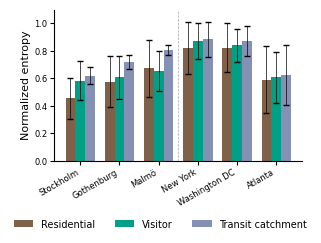

In [51]:
# =============================================================================
# Figure 1a: Bar Chart — Birth Background, w/ Catchment Only
# =============================================================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(mm_to_inch(75), mm_to_inch(60))
)

cities = [CITY_DISPLAY.get(c, c) for c in selected_cities]
x = np.arange(len(cities))
width = 0.25

regime = 'with_catchment'
dim = 'birth'

plot_data = stats_by_regime[
    (stats_by_regime['regime'] == regime) &
    (stats_by_regime['dimension'] == dim) &
    (stats_by_regime['city'].isin(selected_cities))
].copy()

plot_data['display_city'] = plot_data['city'].map(
    lambda c: CITY_DISPLAY.get(c, c)
)

city_order = {
    CITY_DISPLAY.get(c, c): i
    for i, c in enumerate(selected_cities)
}

plot_data = plot_data.sort_values(
    'display_city',
    key=lambda s: s.map(city_order)
)

# Fill missing cities to preserve consistent x-axis order
missing_cities = [
    c for c in selected_cities
    if CITY_DISPLAY.get(c, c) not in plot_data['display_city'].values
]

if missing_cities:
    missing_rows = pd.DataFrame([
        {
            'city': c,
            'display_city': CITY_DISPLAY.get(c, c),
            'dimension': dim,
            'regime': regime,
            'residential_mean': np.nan,
            'residential_std': np.nan,
            'visitor_mean': np.nan,
            'visitor_std': np.nan,
            'catchment_mean': np.nan,
            'catchment_std': np.nan
        }
        for c in missing_cities
    ])

    plot_data = pd.concat([plot_data, missing_rows], ignore_index=True)

    plot_data = plot_data.sort_values(
        'display_city',
        key=lambda s: s.map(city_order)
    )

mtypes = ['residential', 'visitor', 'catchment']
mlabels = ['Residential', 'Visitor', 'Transit catchment']
mcolors = [
    COLORS['residential'],
    COLORS['visitor'],
    COLORS['catchment']
]

legend_handles = []
legend_labels = []

for i, (mtype, label, color) in enumerate(zip(mtypes, mlabels, mcolors)):
    bars = ax.bar(
        x + (i - 1) * width,
        plot_data[f'{mtype}_mean'].values,
        width,
        yerr=plot_data[f'{mtype}_std'].values,
        color=color,
        capsize=2,
        error_kw={'linewidth': 0.5},
        label=label
    )

    legend_handles.append(bars[0])
    legend_labels.append(label)

ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Normalized entropy')

# Sweden / US separator
ax.axvline(
    x=2.5,
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.7
)

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03)
)

plt.subplots_adjust(
    left=0.14,
    right=0.98,
    top=0.88,
    bottom=0.24
)

save_figure(fig, 'fig1a_birth_mixing_with_catchment', formats=['pdf'])
plt.show()


Saved: outputs/figures/fig1c_birth_rtvg_lower_triangle_correlation_matrix.pdf


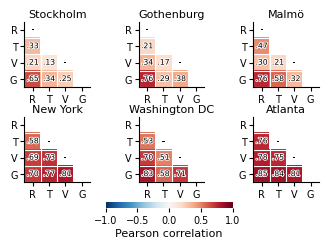

In [49]:
import matplotlib.patheffects as pe

# =============================================================================
# Figure 1c: Lower-triangle POI-level correlation matrices
# Birth background only
# R = residential, T = transit catchment, V = visitor, G = geographic catchment
# 2 rows × 3 columns
# =============================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(mm_to_inch(85), mm_to_inch(60)),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

corr_cols = {
    'R': 'residential_entropy_birth_norm',
    'T': 'catchment_entropy_birth_norm',
    'V': 'visitor_entropy_birth_norm',
    'G': 'geo_catchment_entropy_birth_norm'
}

labels = ['R', 'T', 'V', 'G']

for ax, city in zip(axes, selected_cities):

    city_df = all_pois.loc[
        all_pois['city'].eq(city),
        list(corr_cols.values())
    ].copy()

    city_df = city_df.rename(columns={v: k for k, v in corr_cols.items()})
    city_df = city_df.dropna(subset=labels)

    corr_mat = city_df[labels].corr(method='pearson')

    # Keep lower triangle only
    mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
    mask_diag = np.eye(len(labels), dtype=bool)

    corr_plot = corr_mat.copy()
    corr_plot = corr_plot.mask(mask_upper | mask_diag)

    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        corr_plot.values,
        vmin=-1,
        vmax=1,
        cmap=cmap
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    ax.set_title(
        CITY_DISPLAY.get(city, city),
        fontsize=8,
        pad=3
    )

    # Annotate lower triangle
    for i in range(len(labels)):
        for j in range(len(labels)):

            if j > i:
                continue

            if i == j:
                txt = '-'
            else:
                val = corr_mat.iloc[i, j]
                txt = (
                    f'{val:.2f}'
                    .replace('0.', '.')
                    .replace('-0.', '-.')
                )

            t = ax.text(
                j,
                i,
                txt,
                ha='center',
                va='center',
                fontsize=5.5,
                color='black'
            )

            # Movie subtitle style outline
            t.set_path_effects([
                pe.Stroke(linewidth=1.25, foreground='white'),
                pe.Normal()
            ])

    # Grid
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)

    ax.grid(
        which='minor',
        color='white',
        linestyle='-',
        linewidth=0.8
    )

    ax.tick_params(
        which='minor',
        bottom=False,
        left=False
    )

for ax in axes[len(selected_cities):]:
    ax.axis('off')

# =============================================================================
# Colorbar
# =============================================================================

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.035,
    pad=0.18
)

cbar.set_label(
    'Pearson correlation',
    fontsize=8
)

cbar.ax.tick_params(labelsize=7)
cbar.outline.set_visible(False)

# =============================================================================
# Layout
# =============================================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.90,
    bottom=0.22,
    wspace=0.45,
    hspace=0.45
)

save_figure(
    fig,
    'fig1c_birth_rtvg_lower_triangle_correlation_matrix',
    formats=['pdf']
)

plt.show()

## Diversity Comparison: With vs Without Transit Catchment

Compare the visitor-residential diversity gap between POIs with and without transit catchment data.

In [ ]:
# =============================================================================
# Comparison Table: Visitor vs Residential Diversity by Catchment Regime
# With Statistical Significance Tests
# =============================================================================

import pyperclip
from scipy import stats

def sig_marker(p):
    """Return significance marker."""
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def sig_marker_latex(p):
    """Return significance marker for LaTeX."""
    if pd.isna(p): return ''
    if p < 0.001: return '$^{***}$'
    if p < 0.01: return '$^{**}$'
    if p < 0.05: return '$^{*}$'
    return '$^{ns}$'

def compute_diversity_comparison_with_stats(city_df, dimension='birth'):
    """
    Compute diversity differences with statistical tests:
    1. Wilcoxon signed-rank test for vis vs res within each regime
    2. Return raw differences for between-regime comparison
    """
    res_col = f'residential_entropy_{dimension}_norm'
    vis_col = f'visitor_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    # Split by catchment availability
    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]
    df_without = city_df[~has_catchment]

    results = {}

    # With catchment
    valid_with = df_with[[res_col, vis_col]].dropna()
    if len(valid_with) >= 20:
        diff_with = (valid_with[vis_col] - valid_with[res_col]).values
        try:
            _, p_wilcox = stats.wilcoxon(valid_with[vis_col], valid_with[res_col])
        except:
            p_wilcox = np.nan

        results['with'] = {
            'n': len(valid_with),
            'res_mean': valid_with[res_col].mean(),
            'vis_mean': valid_with[vis_col].mean(),
            'diff_mean': diff_with.mean(),
            'diff_std': diff_with.std(),
            'diff_median': np.median(diff_with),
            'p_wilcox': p_wilcox,
            'diff_array': diff_with,
        }
    else:
        results['with'] = {'n': len(valid_with)}

    # Without catchment
    valid_without = df_without[[res_col, vis_col]].dropna()
    if len(valid_without) >= 20:
        diff_without = (valid_without[vis_col] - valid_without[res_col]).values
        try:
            _, p_wilcox = stats.wilcoxon(valid_without[vis_col], valid_without[res_col])
        except:
            p_wilcox = np.nan

        results['without'] = {
            'n': len(valid_without),
            'res_mean': valid_without[res_col].mean(),
            'vis_mean': valid_without[vis_col].mean(),
            'diff_mean': diff_without.mean(),
            'diff_std': diff_without.std(),
            'diff_median': np.median(diff_without),
            'p_wilcox': p_wilcox,
            'diff_array': diff_without,
        }
    else:
        results['without'] = {'n': len(valid_without)}

    # Difference-of-differences: Mann-Whitney U test
    if 'diff_array' in results.get('with', {}) and 'diff_array' in results.get('without', {}):
        try:
            _, p_mannwhitney = stats.mannwhitneyu(
                results['with']['diff_array'],
                results['without']['diff_array'],
                alternative='two-sided'
            )
            results['diff_of_diff'] = {
                'with_mean': results['with']['diff_mean'],
                'without_mean': results['without']['diff_mean'],
                'delta': results['with']['diff_mean'] - results['without']['diff_mean'],
                'p_mannwhitney': p_mannwhitney,
            }
        except:
            results['diff_of_diff'] = {'p_mannwhitney': np.nan}

    return results

# Compute comparison for all cities
comparison_rows = []
diff_of_diff_rows = []

for city in selected_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        result = compute_diversity_comparison_with_stats(city_df, dim)

        for regime in ['with', 'without']:
            r = result.get(regime, {})
            if 'diff_mean' in r:
                comparison_rows.append({
                    'City': display_name,
                    'Country': country,
                    'Dimension': dim.capitalize(),
                    'Regime': 'With Catchment' if regime == 'with' else 'Without Catchment',
                    'N': r['n'],
                    'Res. Mean': r['res_mean'],
                    'Vis. Mean': r['vis_mean'],
                    'Vis-Res Diff': r['diff_mean'],
                    'Diff Std': r['diff_std'],
                    'p_wilcox': r['p_wilcox'],
                })

        if 'diff_of_diff' in result:
            dod = result['diff_of_diff']
            diff_of_diff_rows.append({
                'City': display_name,
                'Country': country,
                'Dimension': dim.capitalize(),
                'Diff (with)': dod.get('with_mean', np.nan),
                'Diff (without)': dod.get('without_mean', np.nan),
                'Delta': dod.get('delta', np.nan),
                'p_mannwhitney': dod.get('p_mannwhitney', np.nan),
            })

comparison_df = pd.DataFrame(comparison_rows)
diff_of_diff_df = pd.DataFrame(diff_of_diff_rows)

# Display table
print("=" * 140)
print("DIVERSITY COMPARISON: Visitor - Residential by Catchment Regime (with Statistical Tests)")
print("=" * 140)
print("\nWithin-regime test: Wilcoxon signed-rank (paired, vis vs res)")
print("Between-regime test: Mann-Whitney U (independent, comparing vis-res differences)\n")

for dim in ['Birth', 'Income']:
    print(f"\n{'='*60}")
    print(f"  {dim} Dimension")
    print(f"{'='*60}\n")
    print(f"{'City':<14} {'Ctry':<6} | {'With Catchment':^40} | {'Without Catchment':^40} | {'Diff-of-Diff':^18}")
    print(f"{'':<14} {'':<6} | {'N':>8} {'Res':>7} {'Vis':>7} {'Diff':>14} | {'N':>8} {'Res':>7} {'Vis':>7} {'Diff':>14} | {'Delta':>10} {'p':>6}")
    print("-" * 140)

    dim_comp = comparison_df[comparison_df['Dimension'] == dim]
    dim_dod = diff_of_diff_df[diff_of_diff_df['Dimension'] == dim]

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_comp = dim_comp[dim_comp['City'] == city]
        city_dod = dim_dod[dim_dod['City'] == city]

        with_data = city_comp[city_comp['Regime'] == 'With Catchment']
        without_data = city_comp[city_comp['Regime'] == 'Without Catchment']

        country = with_data['Country'].values[0] if len(with_data) > 0 else (
            without_data['Country'].values[0] if len(without_data) > 0 else '')

        if len(with_data) > 0:
            w = with_data.iloc[0]
            with_str = f"{int(w['N']):>8,} {w['Res. Mean']:>7.3f} {w['Vis. Mean']:>7.3f} {w['Vis-Res Diff']:>+.3f}{sig_marker(w['p_wilcox']):>5}"
        else:
            with_str = f"{'--':>8} {'--':>7} {'--':>7} {'--':>14}"

        if len(without_data) > 0:
            wo = without_data.iloc[0]
            without_str = f"{int(wo['N']):>8,} {wo['Res. Mean']:>7.3f} {wo['Vis. Mean']:>7.3f} {wo['Vis-Res Diff']:>+.3f}{sig_marker(wo['p_wilcox']):>5}"
        else:
            without_str = f"{'--':>8} {'--':>7} {'--':>7} {'--':>14}"

        if len(city_dod) > 0:
            dod = city_dod.iloc[0]
            dod_str = f"{dod['Delta']:>+10.3f} {sig_marker(dod['p_mannwhitney']):>6}"
        else:
            dod_str = f"{'--':>10} {'--':>6}"

        print(f"{city:<14} {country:<6} | {with_str} | {without_str} | {dod_str}")

print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("Diff column: Wilcoxon p-value for vis vs res within regime")
print("Delta column: (Diff_with - Diff_without), Mann-Whitney U p-value")

# Save to CSV
comparison_df.to_csv(TABLE_DIR / 'diversity_comparison_by_regime.csv', index=False)
diff_of_diff_df.to_csv(TABLE_DIR / 'diversity_diff_of_diff.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'diversity_comparison_by_regime.csv'}")
print(f"Saved: {TABLE_DIR / 'diversity_diff_of_diff.csv'}")

# Generate LaTeX table
def generate_latex_comparison_table_with_stats(comp_df, dod_df):
    latex_lines = []
    latex_lines.append(r"\begin{table}[htbp]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Visitor vs. Residential Diversity by Transit Catchment Regime}")
    latex_lines.append(r"\label{tab:diversity_comparison}")
    latex_lines.append(r"\footnotesize")
    latex_lines.append(r"\begin{tabular}{llrrrc|rrrc|cc}")
    latex_lines.append(r"\toprule")
    latex_lines.append(r" & & \multicolumn{4}{c}{With Catchment} & \multicolumn{4}{c}{Without Catchment} & \multicolumn{2}{c}{Diff-of-Diff} \\")
    latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-12}")
    latex_lines.append(r"City & Dim. & N & Res. & Vis. & Diff. & N & Res. & Vis. & Diff. & $\Delta$ & p \\")
    latex_lines.append(r"\midrule")

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_comp = comp_df[comp_df['City'] == city]
        city_dod = dod_df[dod_df['City'] == city]

        for dim in ['Birth', 'Income']:
            dim_comp = city_comp[city_comp['Dimension'] == dim]
            dim_dod = city_dod[city_dod['Dimension'] == dim]

            with_data = dim_comp[dim_comp['Regime'] == 'With Catchment']
            without_data = dim_comp[dim_comp['Regime'] == 'Without Catchment']

            city_label = city if dim == 'Birth' else ''

            if len(with_data) > 0:
                w = with_data.iloc[0]
                with_vals = f"{int(w['N']):,} & {w['Res. Mean']:.3f} & {w['Vis. Mean']:.3f} & {w['Vis-Res Diff']:+.3f}{sig_marker_latex(w['p_wilcox'])}"
            else:
                with_vals = r"-- & -- & -- & --"

            if len(without_data) > 0:
                wo = without_data.iloc[0]
                without_vals = f"{int(wo['N']):,} & {wo['Res. Mean']:.3f} & {wo['Vis. Mean']:.3f} & {wo['Vis-Res Diff']:+.3f}{sig_marker_latex(wo['p_wilcox'])}"
            else:
                without_vals = r"-- & -- & -- & --"

            if len(dim_dod) > 0:
                dod = dim_dod.iloc[0]
                dod_vals = f"{dod['Delta']:+.3f} & {sig_marker_latex(dod['p_mannwhitney']).replace('$', '')}"
            else:
                dod_vals = r"-- & --"

            latex_lines.append(f"{city_label} & {dim} & {with_vals} & {without_vals} & {dod_vals} \\\\")

        if city != CITY_DISPLAY.get(selected_cities[-1], selected_cities[-1]):
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.append(r"\bottomrule")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append(r"\\[5pt]")
    latex_lines.append(r"\raggedright\footnotesize{Diff.: Wilcoxon signed-rank test (vis vs res within regime). $\Delta$: difference-of-differences (with $-$ without), Mann-Whitney U test.}")
    latex_lines.append(r"\\")
    latex_lines.append(r"\raggedright\footnotesize{$^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$not significant.}")
    latex_lines.append(r"\end{table}")

    return '\n'.join(latex_lines)

latex_table = generate_latex_comparison_table_with_stats(comparison_df, diff_of_diff_df)
try:
    pyperclip.copy(latex_table)
    print("\nLaTeX table copied to clipboard!")
except:
    print("\nCould not copy to clipboard. LaTeX table:")
    print(latex_table)

## Statistical Tests: Pairwise Comparisons by Catchment Regime

In [55]:
# =============================================================================
# Statistical Tests: W/ Transit Catchment Analysis — All Cities
# =============================================================================
# 1. Within w/ catchment: res vs vis, res vs cat, (vis-res) vs (cat-res)
# 2. Between regimes: residential diversity comparison (w/ vs w/o catchment)
# =============================================================================

from scipy import stats
import numpy as np
import pandas as pd
import pyperclip

def sig_marker(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def sig_marker_latex(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '$^{***}$'
    if p < 0.01:
        return '$^{**}$'
    if p < 0.05:
        return '$^{*}$'
    return '$^{ns}$'

# =============================================================================
# City order: include all available cities
# =============================================================================

DEFAULT_CITY_ORDER = [
    'stockholm',
    'gothenburg',
    'malmo',
    'uppsala',
    'linkoping',
    'vasteras',
    'orebro',
    'helsingborg',
    'lund',
    'new_york',
    'washington_dc',
    'atlanta'
]

available_cities = set(all_pois['city'].dropna().unique())

analysis_cities = [
    c for c in DEFAULT_CITY_ORDER
    if c in available_cities
]

analysis_cities += sorted(
    c for c in available_cities
    if c not in analysis_cities
)

def compute_with_catchment_tests(city_df, dimension='birth'):
    """
    Compute tests for POIs WITH transit catchment:
    1. res vs vis
    2. res vs cat
    3. (vis-res) vs (cat-res)
    """
    res_col = f'residential_entropy_{dimension}_norm'
    vis_col = f'visitor_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]

    valid = df_with[[res_col, vis_col, cat_col]].dropna()
    n = len(valid)

    results = {'n': n}

    if n >= 20:
        res_vals = valid[res_col]
        vis_vals = valid[vis_col]
        cat_vals = valid[cat_col]

        results['res_mean'] = res_vals.mean()
        results['vis_mean'] = vis_vals.mean()
        results['cat_mean'] = cat_vals.mean()

        try:
            _, p_vis_res = stats.wilcoxon(vis_vals, res_vals)
            results['vis_res_diff'] = (vis_vals - res_vals).mean()
            results['vis_res_p'] = p_vis_res
        except Exception:
            results['vis_res_diff'] = np.nan
            results['vis_res_p'] = np.nan

        try:
            _, p_cat_res = stats.wilcoxon(cat_vals, res_vals)
            results['cat_res_diff'] = (cat_vals - res_vals).mean()
            results['cat_res_p'] = p_cat_res
        except Exception:
            results['cat_res_diff'] = np.nan
            results['cat_res_p'] = np.nan

        try:
            diff_vis_res = vis_vals - res_vals
            diff_cat_res = cat_vals - res_vals
            _, p_diff_diff = stats.wilcoxon(diff_vis_res, diff_cat_res)
            results['diff_of_diff'] = diff_vis_res.mean() - diff_cat_res.mean()
            results['diff_of_diff_p'] = p_diff_diff
        except Exception:
            results['diff_of_diff'] = np.nan
            results['diff_of_diff_p'] = np.nan

    return results

def compute_residential_between_regimes(city_df, dimension='birth'):
    """
    Compare residential diversity between POIs with and without catchment.
    Uses Mann-Whitney U test.
    """
    res_col = f'residential_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]
    df_without = city_df[~has_catchment]

    res_with = df_with[res_col].dropna()
    res_without = df_without[res_col].dropna()

    results = {
        'n_with': len(res_with),
        'n_without': len(res_without),
    }

    if len(res_with) >= 20 and len(res_without) >= 20:
        results['res_mean_with'] = res_with.mean()
        results['res_mean_without'] = res_without.mean()
        results['res_diff'] = res_with.mean() - res_without.mean()

        try:
            _, p_mw = stats.mannwhitneyu(
                res_with,
                res_without,
                alternative='two-sided'
            )
            results['p_mannwhitney'] = p_mw
        except Exception:
            results['p_mannwhitney'] = np.nan

    return results

# =============================================================================
# Part 1: W/ Catchment Tests
# =============================================================================

print("=" * 120)
print("PART 1: Statistical Tests for POIs WITH Transit Catchment")
print("=" * 120)
print("\nTests: (1) Vis vs Res, (2) Cat vs Res, (3) (Vis-Res) vs (Cat-Res)")
print("Method: Wilcoxon signed-rank test\n")

print(
    f"{'City':<16} {'Dim':<8} {'N':>8} {'Res':>7} {'Vis':>7} {'Cat':>7} | "
    f"{'Vis-Res':>14} {'Cat-Res':>14} {'DiffOfDiff':>14}"
)
print("-" * 120)

with_catchment_results = []

for city in analysis_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        r = compute_with_catchment_tests(city_df, dim)

        if 'res_mean' in r:
            with_catchment_results.append({
                'city': display_name,
                'city_key': city,
                'country': country,
                'dimension': dim.capitalize(),
                **r
            })

            vr_str = f"{r['vis_res_diff']:+.3f}{sig_marker(r['vis_res_p']):>4}"
            cr_str = f"{r['cat_res_diff']:+.3f}{sig_marker(r['cat_res_p']):>4}"
            dd_str = f"{r['diff_of_diff']:+.3f}{sig_marker(r['diff_of_diff_p']):>4}"

            print(
                f"{display_name:<16} {dim.capitalize():<8} {r['n']:>8,} "
                f"{r['res_mean']:>7.3f} {r['vis_mean']:>7.3f} {r['cat_mean']:>7.3f} | "
                f"{vr_str:>14} {cr_str:>14} {dd_str:>14}"
            )
        else:
            print(
                f"{display_name:<16} {dim.capitalize():<8} {r['n']:>8,} "
                "-- insufficient data --"
            )

with_catchment_df = pd.DataFrame(with_catchment_results)

# =============================================================================
# Part 2: Residential Diversity Comparison
# =============================================================================

print("\n" + "=" * 120)
print("PART 2: Residential Diversity Comparison: w/ vs w/o Catchment POIs")
print("=" * 120)
print("\nMethod: Mann-Whitney U test\n")

print(
    f"{'City':<16} {'Dim':<8} | {'N (w/)':>10} {'Res (w/)':>10} | "
    f"{'N (w/o)':>10} {'Res (w/o)':>10} | {'Diff':>10} {'p':>8}"
)
print("-" * 100)

residential_comparison_results = []

for city in analysis_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        r = compute_residential_between_regimes(city_df, dim)

        if 'res_mean_with' in r:
            residential_comparison_results.append({
                'city': display_name,
                'city_key': city,
                'country': country,
                'dimension': dim.capitalize(),
                **r
            })

            diff_str = f"{r['res_diff']:+.3f}"
            p_str = sig_marker(r['p_mannwhitney'])

            print(
                f"{display_name:<16} {dim.capitalize():<8} | "
                f"{r['n_with']:>10,} {r['res_mean_with']:>10.3f} | "
                f"{r['n_without']:>10,} {r['res_mean_without']:>10.3f} | "
                f"{diff_str:>10} {p_str:>8}"
            )
        else:
            print(
                f"{display_name:<16} {dim.capitalize():<8} | "
                f"{r['n_with']:>10,} {'--':>10} | "
                f"{r['n_without']:>10,} {'--':>10} | "
                f"{'--':>10} {'--':>8}"
            )

residential_comparison_df = pd.DataFrame(residential_comparison_results)

print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Save results
with_catchment_df.to_csv(TABLE_DIR / 'stat_with_catchment_tests.csv', index=False)
residential_comparison_df.to_csv(TABLE_DIR / 'stat_residential_comparison.csv', index=False)

print(f"\nSaved: {TABLE_DIR / 'stat_with_catchment_tests.csv'}")
print(f"Saved: {TABLE_DIR / 'stat_residential_comparison.csv'}")

# =============================================================================
# Generate LaTeX Tables
# =============================================================================

def generate_latex_with_catchment_table(df, dimensions=('Birth', 'Income')):
    """Generate LaTeX table for w/ catchment tests."""
    latex_lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\caption{Diversity comparisons for POIs with transit catchment. Wilcoxon signed-rank tests compare visitor, residential, and transit catchment diversity.}",
        r"\label{tab:with_catchment_tests}",
        r"\footnotesize",
        r"\begin{tabular}{llrrrrccc}",
        r"\toprule",
        r"City & Dim. & N & Res. & Vis. & Cat. & Vis$-$Res & Cat$-$Res & $\Delta$ \\",
        r"\midrule"
    ]

    ordered_display_cities = [CITY_DISPLAY.get(c, c) for c in analysis_cities]

    for idx, city in enumerate(ordered_display_cities):
        city_data = df[df['city'] == city]

        for dim in dimensions:
            row = city_data[city_data['dimension'] == dim]
            if len(row) > 0:
                r = row.iloc[0]
                city_label = city if dim == dimensions[0] else ''
                vr_val = f"{r['vis_res_diff']:+.3f}{sig_marker_latex(r['vis_res_p'])}"
                cr_val = f"{r['cat_res_diff']:+.3f}{sig_marker_latex(r['cat_res_p'])}"
                dd_val = f"{r['diff_of_diff']:+.3f}{sig_marker_latex(r['diff_of_diff_p'])}"

                latex_lines.append(
                    f"{city_label} & {dim} & {int(r['n']):,} & "
                    f"{r['res_mean']:.3f} & {r['vis_mean']:.3f} & {r['cat_mean']:.3f} & "
                    f"{vr_val} & {cr_val} & {dd_val} \\\\"
                )

        if idx < len(ordered_display_cities) - 1:
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\\[5pt]",
        r"\raggedright\footnotesize{$\Delta$ = (Vis$-$Res) $-$ (Cat$-$Res). $^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$ not significant.}",
        r"\end{table}"
    ])

    return '\n'.join(latex_lines)

def generate_latex_residential_comparison_table(df, dimensions=('Birth', 'Income')):
    """Generate LaTeX table for residential comparison between regimes."""
    latex_lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\caption{Residential diversity comparison between POIs with and without transit catchment. Mann-Whitney U tests compare independent samples.}",
        r"\label{tab:residential_comparison}",
        r"\footnotesize",
        r"\begin{tabular}{llrrrrrr}",
        r"\toprule",
        r" & & \multicolumn{2}{c}{w/ Catchment} & \multicolumn{2}{c}{w/o Catchment} & & \\",
        r"\cmidrule(lr){3-4} \cmidrule(lr){5-6}",
        r"City & Dim. & N & Res. & N & Res. & Diff. & p \\",
        r"\midrule"
    ]

    ordered_display_cities = [CITY_DISPLAY.get(c, c) for c in analysis_cities]

    for idx, city in enumerate(ordered_display_cities):
        city_data = df[df['city'] == city]

        for dim in dimensions:
            row = city_data[city_data['dimension'] == dim]
            if len(row) > 0:
                r = row.iloc[0]
                city_label = city if dim == dimensions[0] else ''
                diff_val = f"{r['res_diff']:+.3f}"
                p_val = sig_marker_latex(r['p_mannwhitney'])

                latex_lines.append(
                    f"{city_label} & {dim} & {int(r['n_with']):,} & "
                    f"{r['res_mean_with']:.3f} & {int(r['n_without']):,} & "
                    f"{r['res_mean_without']:.3f} & {diff_val} & {p_val} \\\\"
                )

        if idx < len(ordered_display_cities) - 1:
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\\[5pt]",
        r"\raggedright\footnotesize{Diff. = Res.(w/) $-$ Res.(w/o). $^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$ not significant.}",
        r"\end{table}"
    ])

    return '\n'.join(latex_lines)

latex_with_catchment = generate_latex_with_catchment_table(with_catchment_df)
latex_residential = generate_latex_residential_comparison_table(residential_comparison_df)

combined_latex = latex_with_catchment + "\n\n" + latex_residential

try:
    pyperclip.copy(combined_latex)
    print("\nBoth LaTeX tables copied to clipboard!")
except Exception:
    print("\nCould not copy to clipboard. LaTeX tables:")
    print(combined_latex)


PART 1: Statistical Tests for POIs WITH Transit Catchment

Tests: (1) Vis vs Res, (2) Cat vs Res, (3) (Vis-Res) vs (Cat-Res)
Method: Wilcoxon signed-rank test

City             Dim             N     Res     Vis     Cat |        Vis-Res        Cat-Res     DiffOfDiff
------------------------------------------------------------------------------------------------------------------------
New York         Birth     148,413   0.825   0.873   0.887 |     +0.048 ***     +0.062 ***     -0.014 ***
New York         Income    111,233   0.875   0.607   0.894 |     -0.268 ***     +0.019 ***     -0.286 ***
Washington DC    Birth      24,599   0.826   0.840   0.872 |     +0.014  ns     +0.046 ***     -0.032 ***
Washington DC    Income     18,750   0.804   0.569   0.674 |     -0.236 ***     -0.130 ***     -0.106 ***
Atlanta          Birth      34,354   0.592   0.607   0.626 |     +0.015 ***     +0.034 ***     -0.019 ***
Atlanta          Income     32,312   0.889   0.600   0.476 |     -0.289 ***     -0.

## Table 1 Spatial Clustering (Moran's I + LISA Summary) - Combined

In [53]:
# Table 1-Full: Spatial Clustering for ALL 12 Cities (Moran's I + LISA)
# N POIs from source data (filtered: valid visitor + catchment entropy)
# Moran's I and LISA percentages from lisa_summary.csv

import pandas as pd

# Get TRUE POI counts from source data (with analysis-ready filter)
us_pois_src = pd.read_parquet('dbs/routing/us_poi_diversity_metrics.parquet')
sweden_pois_src = pd.read_parquet('dbs/routing/sweden_poi_diversity_metrics.parquet')

# Filter: must have both visitor and catchment diversity
us_filtered = us_pois_src[
    us_pois_src['visitor_entropy_birth_norm'].notna() & 
    us_pois_src['catchment_entropy_birth_norm'].notna()
]
sweden_filtered = sweden_pois_src[
    sweden_pois_src['visitor_entropy_birth_norm'].notna() & 
    sweden_pois_src['catchment_entropy_birth_norm'].notna()
]

# Get counts per city
poi_counts = {}
for city, count in us_filtered.groupby('city').size().items():
    poi_counts[city] = count
for city, count in sweden_filtered.groupby('city').size().items():
    poi_counts[city] = count

# Load LISA summary (has Moran's I and cluster percentages)
lisa_summary = pd.read_csv('outputs/phase2/lisa_summary.csv')

# Define the 12 cities for main analysis
TARGET_CITIES = {
    'Stockholm': 'Sweden', 'Göteborg': 'Sweden', 'Malmö': 'Sweden',
    'Uppsala': 'Sweden', 'Västerås': 'Sweden', 'Örebro': 'Sweden',
    'Linköping': 'Sweden', 'Helsingborg': 'Sweden', 'Lund': 'Sweden',
    'new_york': 'US', 'washington_dc': 'US', 'atlanta': 'US'
}

CITY_DISPLAY = {
    'Stockholm': 'Stockholm', 'Göteborg': 'Gothenburg', 'Malmö': 'Malmö',
    'Uppsala': 'Uppsala', 'Västerås': 'Västerås', 'Örebro': 'Örebro',
    'Linköping': 'Linköping', 'Helsingborg': 'Helsingborg', 'Lund': 'Lund',
    'new_york': 'New York', 'washington_dc': 'Washington DC', 'atlanta': 'Atlanta'
}

table1_data = []

for city, country in TARGET_CITIES.items():
    # Get LISA data
    lisa_birth = lisa_summary[(lisa_summary['city'] == city) & (lisa_summary['entropy_type'] == 'birth')]
    lisa_income = lisa_summary[(lisa_summary['city'] == city) & (lisa_summary['entropy_type'] == 'income')]
    
    if len(lisa_birth) == 0:
        print(f"Warning: No LISA data for {city}")
        continue
    
    row = {
        'City': CITY_DISPLAY.get(city, city),
        'Country': country,
        'N POIs': poi_counts.get(city, 0),
        # Birth dimension - Moran's I from lisa_summary
        "Moran's I (Birth)": lisa_birth['global_moran_i'].values[0],
        'HH% (Birth)': lisa_birth['pct_high_high'].values[0],
        'LL% (Birth)': lisa_birth['pct_low_low'].values[0],
        # Income dimension
        "Moran's I (Income)": lisa_income['global_moran_i'].values[0] if len(lisa_income) > 0 else None,
        'HH% (Income)': lisa_income['pct_high_high'].values[0] if len(lisa_income) > 0 else None,
        'LL% (Income)': lisa_income['pct_low_low'].values[0] if len(lisa_income) > 0 else None,
    }
    table1_data.append(row)

table1_full = pd.DataFrame(table1_data)

# Sort: Sweden first (alphabetically), then US (by size)
table1_full['sort_key'] = table1_full.apply(
    lambda r: (0, r['City']) if r['Country'] == 'Sweden' else (1, -r['N POIs']), axis=1
)
table1_full = table1_full.sort_values('sort_key').drop(columns='sort_key')

# Display formatted
print("Table 1: Spatial Clustering Summary (Full 12 Cities)")
print("=" * 120)
display_df = table1_full.copy()
display_df['N POIs'] = display_df['N POIs'].apply(lambda x: f"{x:,}")
for col in display_df.columns:
    if "Moran" in col:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else '-')
    elif '%' in col:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else '-')
print(display_df.to_string(index=False))

# Save
table1_full.to_csv(TABLE_DIR / 'table1_full_spatial_clustering.csv', index=False)
print(f"Saved: {TABLE_DIR / 'table1_full_spatial_clustering.csv'}")


Table 1: Spatial Clustering Summary (Full 12 Cities)
         City Country  N POIs Moran's I (Birth) HH% (Birth) LL% (Birth) Moran's I (Income) HH% (Income) LL% (Income)
   Gothenburg  Sweden  16,685             0.237        9.3%       14.5%              0.082         8.5%         3.6%
  Helsingborg  Sweden   5,275             0.161       11.4%       10.7%              0.077         9.1%         3.5%
    Linköping  Sweden   5,311             0.182        7.4%       10.1%              0.149         8.7%         3.8%
         Lund  Sweden   4,824             0.081        5.0%        5.7%              0.098         9.8%         3.1%
        Malmö  Sweden  12,610             0.197       14.3%       12.8%              0.049        10.4%         3.7%
    Stockholm  Sweden  35,842             0.127        6.0%        5.6%              0.075        11.9%         4.9%
      Uppsala  Sweden   7,933             0.167       10.7%       10.1%              0.067        12.8%         2.3%
     Väster

---
# SECTION 2: Transit Catchment Effects (Spatial Regression Analysis)

Examining how transit catchment diversity predicts visitor diversity.

In [12]:
spillover_birth['city'] = spillover_birth['city'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else x)
spillover_income['city'] = spillover_income['city'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else x)

Saved: outputs/figures/fig3_regression_coefficients.pdf
Saved: outputs/figures/fig3_regression_coefficients.png


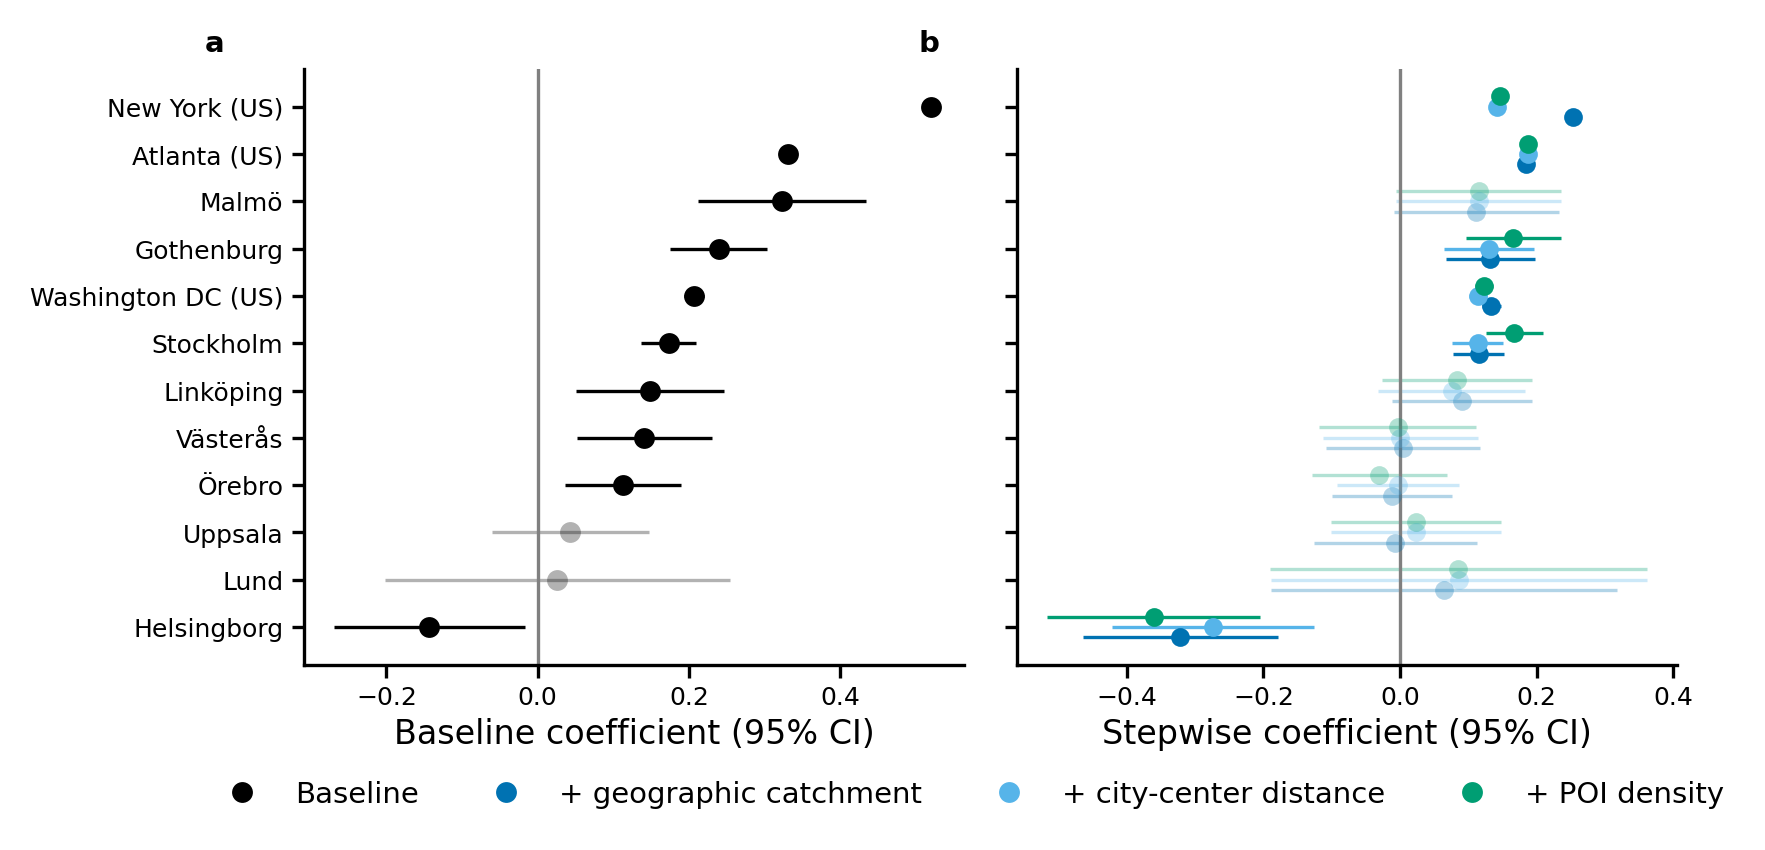

In [20]:
# Figure 3: Baseline and Stepwise Coefficient Comparison
# Birth-background transit catchment coefficients from OLS across cities
# Lighter color for non-significant coefficients (p >= 0.05)

from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    1, 2,
    figsize=(mm_to_inch(150), mm_to_inch(72)),
    dpi=300,
    sharey=True
)

def get_alpha(p):
    """Return alpha value based on significance."""
    return 1.0 if p < 0.05 else 0.3

def normalize_city_name(city):
    """Normalize city labels from result tables for plotting alignment."""
    city = str(city).split(' - ')[-1]
    replacements = {
        'GÃ¶teborg': 'Göteborg',
        'MalmÃ¶': 'Malmö',
        'VÃ¤sterÃ¥s': 'Västerås',
        'Ã–rebro': 'Örebro',
        'LinkÃ¶ping': 'Linköping',
    }
    return replacements.get(city, city)

def display_city(city):
    """Return display label, marking US cities explicitly."""
    return f"{CITY_DISPLAY.get(city, city)} (US)" if city in US_CITIES else CITY_DISPLAY.get(city, city)

# Panel (a): Baseline OLS, birth background only
ax = axes[0]
baseline = spillover_birth.copy()
baseline['city_key'] = baseline['city'].apply(normalize_city_name)
baseline['display_name'] = baseline['city_key'].apply(display_city)
baseline = baseline.sort_values('ols_catchment_coef', ascending=True).reset_index(drop=True)

y_pos = np.arange(len(baseline))
city_to_y = dict(zip(baseline['city_key'], y_pos))

for i, (_, row) in enumerate(baseline.iterrows()):
    alpha = get_alpha(row['ols_catchment_p'])
    ax.errorbar(row['ols_catchment_coef'], i, 
                xerr=row['ols_catchment_se'] * 1.96,
                fmt='o', markersize=5, color='black', ecolor='black',
                markeredgewidth=0, capsize=2, capthick=0.6,
                elinewidth=0.8, alpha=alpha)

ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(baseline['display_name'], color='black')
ax.set_xlabel('Baseline coefficient (95% CI)')
ax.text(-0.15, 1.02, 'a', transform=ax.transAxes, fontweight='bold', va='bottom')

# Panel (b): Stepwise OLS robustness, birth background only
ax = axes[1]
stepwise = pd.read_csv('outputs/robustness/stepwise_ols_results.csv')
stepwise = stepwise[
    (stepwise['entropy_type'] == 'birth') &
    (stepwise['spec'] != 'Base')
].copy()
stepwise['city_key'] = stepwise['city'].apply(normalize_city_name)
stepwise = stepwise[stepwise['city_key'].isin(city_to_y)].copy()

spec_order = ['+ Geo Catchment', '+ Geo + Centrality', 'Full']
spec_labels = {
    '+ Geo Catchment': '+ geographic catchment',
    '+ Geo + Centrality': '+ city-center distance',
    'Full': '+ POI density',
}
spec_colors = {
    '+ Geo Catchment': '#0072B2',
    '+ Geo + Centrality': '#56B4E9',
    'Full': '#009E73',
}
spec_offsets = {
    '+ Geo Catchment': -0.22,
    '+ Geo + Centrality': 0.0,
    'Full': 0.22,
}

for spec in spec_order:
    spec_data = stepwise[stepwise['spec'] == spec].copy()
    spec_data['y'] = spec_data['city_key'].map(city_to_y) + spec_offsets[spec]
    for _, row in spec_data.iterrows():
        alpha = get_alpha(row['catchment_p'])
        ax.errorbar(row['catchment_coef'], row['y'],
                    xerr=row['catchment_se'] * 1.96,
                    fmt='o', markersize=4.5, color=spec_colors[spec],
                    ecolor=spec_colors[spec], markeredgewidth=0,
                    capsize=0, elinewidth=0.8, alpha=alpha)

ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(baseline['display_name'], color='black')
ax.set_xlabel('Stepwise coefficient (95% CI)')
ax.text(-0.15, 1.02, 'b', transform=ax.transAxes, fontweight='bold', va='bottom')

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='black',
           markeredgewidth=0, markersize=5, label='Baseline'),
] + [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=spec_colors[spec],
           markeredgewidth=0, markersize=5, label=spec_labels[spec])
    for spec in spec_order
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.subplots_adjust(wspace=0.08, bottom=0.18)
save_figure(fig, 'fig3_regression_coefficients')
plt.show()

In [23]:
# Table 2: Model Performance (OLS and Spatial Lag Models)
# Long format: one row per city-dimension, showing OLS, W1, W2 results

def sig_marker(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

table2_data = []

for dim, df in [('Birth', spillover_birth), ('Income', spillover_income)]:
    for _, row in df.iterrows():
        city = row['city']

        table2_data.append({
            'City': CITY_DISPLAY.get(city, city),
            'Country': 'US' if city in US_CITIES else 'Sweden',
            'Dim': dim,
            'N': int(row['n']),
            'OLS R²': row['ols_r2'],
            'W1 ρ': row['w1_rho'],
            'W1 ρ_p': row['w1_rho_p'],
            'W1 R²': row['w1_pr2'],
            'W2 ρ': row['w2_rho'],
            'W2 ρ_p': row['w2_rho_p'],
            'W2 R²': row['w2_pr2'],
        })

table2 = pd.DataFrame(table2_data)
table2 = table2.sort_values(['Country', 'City', 'Dim'], ascending=[True, True, True])

# Display with formatting
print("Table 2: Model Performance (OLS and Spatial Lag Models)")
print("=" * 110)
print(f"{'City':<20} {'Dim':<6} {'N':>10} | {'OLS R²':>8} | {'W1 ρ':>12} {'W1 R²':>8} | {'W2 ρ':>12} {'W2 R²':>8}")
print("-" * 110)

for _, row in table2.iterrows():
    city_label = row['City'] if row['Dim'] == 'Birth' else ''
    n_str = f"{row['N']:,}" if row['Dim'] == 'Birth' else ''

    ols_r2 = f"{row['OLS R²']:.3f}" if pd.notna(row['OLS R²']) else '-'

    w1_rho = f"{row['W1 ρ']:.3f}{sig_marker(row['W1 ρ_p'])}" if pd.notna(row['W1 ρ']) else '-'
    w1_r2 = f"{row['W1 R²']:.3f}" if pd.notna(row['W1 R²']) else '-'

    w2_rho = f"{row['W2 ρ']:.3f}{sig_marker(row['W2 ρ_p'])}" if pd.notna(row['W2 ρ']) else '-'
    w2_r2 = f"{row['W2 R²']:.3f}" if pd.notna(row['W2 R²']) else '-'

    print(f"{city_label:<20} {row['Dim']:<6} {n_str:>10} | {ols_r2:>8} | {w1_rho:>12} {w1_r2:>8} | {w2_rho:>12} {w2_r2:>8}")

print("\n*** p<0.001, ** p<0.01, * p<0.05")

# Save (drop p-value columns for cleaner CSV)
table2_save = table2.drop(columns=['W1 ρ_p', 'W2 ρ_p'])
table2_save.to_csv(TABLE_DIR / 'table2_model_performance.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'table2_model_performance.csv'}")

Table 2: Model Performance (OLS and Spatial Lag Models)
City                 Dim             N |   OLS R² |         W1 ρ    W1 R² |         W2 ρ    W2 R²
--------------------------------------------------------------------------------------------------------------
Gothenburg           Birth       7,677 |    0.120 |     0.848***    0.193 |            -        -
                     Income            |    0.009 |     0.783***    0.028 |            -        -
Helsingborg          Birth       2,380 |    0.070 |     0.891***    0.099 |            -        -
                     Income            |    0.007 |        0.940    0.025 |            -        -
Linköping            Birth       2,328 |    0.052 |     0.908***    0.089 |            -        -
                     Income            |    0.046 |     1.274***    0.078 |            -        -
Lund                 Birth       2,000 |    0.015 |       0.563*    0.020 |            -        -
                     Income            |    0.013

In [22]:
# Appendix Table: Full Regression Results
# Save complete regression table for appendix

appendix_data = []

for _, row in spillover_birth.iterrows():
    city = row['city']
    appendix_data.append({
        'City': CITY_DISPLAY.get(city, city),
        'Country': 'US' if city in US_CITIES else 'Sweden',
        'Entropy Type': 'Birth',
        'N': int(row['n']),
        'OLS R2': row['ols_r2'],
        'Catchment Coef': row['ols_catchment_coef'],
        'Catchment SE': row['ols_catchment_se'],
        'Catchment t': row['ols_catchment_t'],
        'Catchment p': row['ols_catchment_p'],
        'W1 rho': row['w1_rho'],
        'W1 rho SE': row['w1_rho_se'],
        'W1 Pseudo-R2': row['w1_pr2'],
        'W2 rho': row['w2_rho'],
        'W2 Pseudo-R2': row['w2_pr2'],
    })

for _, row in spillover_income.iterrows():
    city = row['city']
    appendix_data.append({
        'City': CITY_DISPLAY.get(city, city),
        'Country': 'US' if city in US_CITIES else 'Sweden',
        'Entropy Type': 'Income',
        'N': int(row['n']),
        'OLS R2': row['ols_r2'],
        'Catchment Coef': row['ols_catchment_coef'],
        'Catchment SE': row['ols_catchment_se'],
        'Catchment t': row['ols_catchment_t'],
        'Catchment p': row['ols_catchment_p'],
        'W1 rho': row['w1_rho'],
        'W1 rho SE': row['w1_rho_se'],
        'W1 Pseudo-R2': row['w1_pr2'],
        'W2 rho': row['w2_rho'],
        'W2 Pseudo-R2': row['w2_pr2'],
    })

appendix_table = pd.DataFrame(appendix_data)
appendix_table.to_csv(TABLE_DIR / 'appendix_full_regression.csv', index=False)
print(f"Saved: {TABLE_DIR / 'appendix_full_regression.csv'}")

Saved: outputs/tables/appendix_full_regression.csv


---
# SECTION 3: Spatially Uneven Effects of Transit Catchments on Social Mixing

GWR reveals where transit catchment effects are strongest and where they are weakest.

In [24]:
# Table 3: GWR Summary Statistics (All POIs)
# Uses only the 'all' category results (not by-category)

# Filter to 'all' category only
gwr_all = gwr_df[gwr_df['venue_category'] == 'all'].copy()
coef_all = coef_df[coef_df['venue_category'] == 'all'].copy()

if len(gwr_all) == 0:
    print("ERROR: No 'all' category results found. Run GWR with --category all first.")
else:
    table3_data = []

    for entropy in ['birth', 'income']:
        subset = gwr_all[gwr_all['entropy_type'] == entropy]
        coef_subset = coef_all[coef_all['entropy_type'] == entropy]
        
        for _, row in subset.iterrows():
            city = row['city']
            city_coefs = coef_subset[coef_subset['city'] == city]['beta_catchment']
            
            # Get simplified city name
            simple_city = city.replace('Sweden - ', '').replace('US - ', '')
            
            table3_data.append({
                'City': CITY_DISPLAY.get(simple_city, simple_city),
                'Country': 'US' if 'US' in city else 'Sweden',
                'Dimension': entropy.capitalize(),
                'N POIs': int(row['n']),
                'Mean Coef': city_coefs.mean(),
                'SD Coef': city_coefs.std(),
                'Min Coef': city_coefs.min(),
                'Max Coef': city_coefs.max(),
                '% Positive': 100 * (city_coefs > 0).mean(),
                '% Hotspot': row['hotspot_pct'],
                '% Coldspot': row['coldspot_pct'],
                'Mean R2': row['r2'],
            })

    table3 = pd.DataFrame(table3_data)
    table3 = table3.sort_values(['Dimension', 'Country', 'N POIs'], ascending=[True, True, False])

    # Display
    print("Table 3: GWR Summary - Spatial Heterogeneity (All POIs)")
    print("=" * 140)
    display_df = table3.copy()
    display_df['N POIs'] = display_df['N POIs'].apply(lambda x: f"{x:,}")
    for col in ['Mean Coef', 'SD Coef', 'Min Coef', 'Max Coef', 'Mean R2']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else '-')
    for col in ['% Positive', '% Hotspot', '% Coldspot']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else '-')
    print(display_df.to_string(index=False))

    # Save
    table3.to_csv(TABLE_DIR / 'table3_gwr_summary.csv', index=False)
    print(f"Saved: {TABLE_DIR / 'table3_gwr_summary.csv'}")

Table 3: GWR Summary - Spatial Heterogeneity (All POIs)
         City Country Dimension  N POIs Mean Coef SD Coef Min Coef  Max Coef % Positive % Hotspot % Coldspot Mean R2
    Stockholm  Sweden     Birth  35,842     0.187   1.350   -7.868     8.927      53.9%      0.5%       1.2%   0.118
   Gothenburg  Sweden     Birth  16,685     0.225   1.685  -10.262    13.122      51.1%      0.8%       0.4%   0.225
        Malmö  Sweden     Birth  12,610    -0.123   1.731   -7.959     6.925      47.7%      0.3%       1.1%   0.182
      Uppsala  Sweden     Birth   7,933    -0.124   2.960  -19.728    13.446      52.5%      0.3%       2.6%   0.185
       Örebro  Sweden     Birth   5,407    -0.275   1.729  -18.764     5.618      45.4%      1.0%       0.0%   0.141
    Linköping  Sweden     Birth   5,311     0.213   2.090  -13.388    14.053      55.5%      1.0%       0.1%   0.186
  Helsingborg  Sweden     Birth   5,275    -0.117   1.358   -2.919     5.158      29.3%      6.1%       8.8%   0.128
     Väs

---
## Section 3B: Category-Level Analysis

GWR was run separately by POI category. This reveals which venue types show stronger transit-mixing relationships.

In [26]:
# Load by-category GWR results (excluding 'all' category)
# This is needed for category-level analysis in Figure 6

gwr_by_category = gwr_df[~gwr_df['venue_category'].isin(['all', 'other'])].copy()
print(f"By-category GWR results: {len(gwr_by_category)} runs")
print(f"Categories: {gwr_by_category['venue_category'].unique().tolist()}")
print(f"POIs by category:")
print(gwr_by_category.groupby('venue_category')['n'].sum().sort_values(ascending=False))

By-category GWR results: 92 runs
Categories: ['food_dining', 'entertainment_recreation', 'accommodation_travel', 'education_higher', 'civic_community']
POIs by category:
venue_category
food_dining                 137979
entertainment_recreation     29428
accommodation_travel         14160
education_higher              6440
civic_community               2244
Name: n, dtype: int64


Saved: outputs/figures/fig6_category_hotspot_rate.pdf
Saved: outputs/figures/fig6_category_hotspot_rate.png


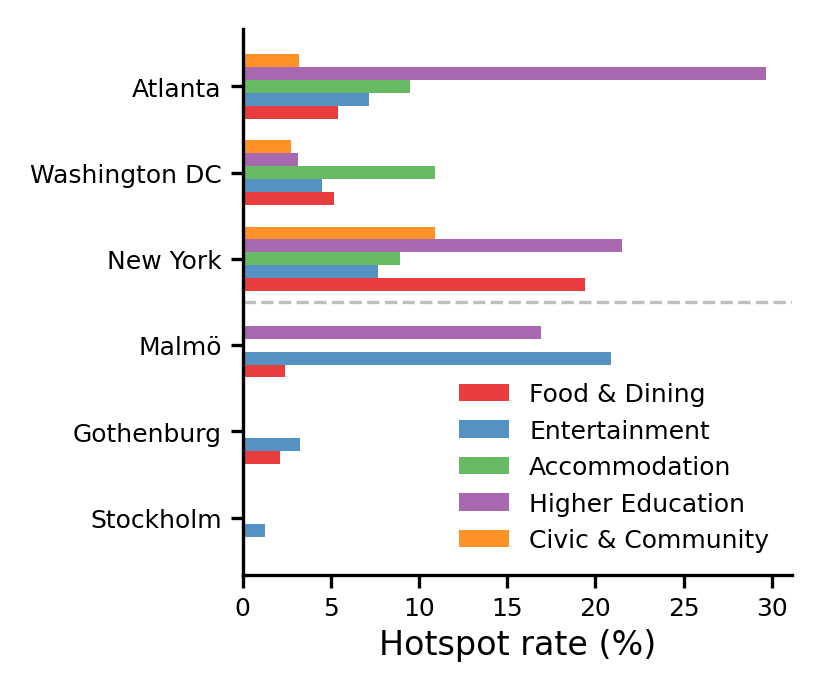


Category-level hotspot rates by city (Birth Background):
category_display  Food & Dining  Entertainment  Accommodation  Higher Education  Civic & Community
city_display                                                                                      
Stockholm                   0.0            1.3            0.0               0.0                0.0
Gothenburg                  2.1            3.3            0.0               0.0                NaN
Malmö                       2.4           20.9            0.0              16.9                NaN
New York                   19.4            7.7            8.9              21.5               10.9
Washington DC               5.2            4.5           10.9               3.2                2.7
Atlanta                     5.4            7.2            9.5              29.6                3.2


In [95]:
# Figure 6: Hotspot Rate by POI Category (Birth Background Only)
# Compare which venue types have highest transit-mixing potential by city

CATEGORY_DISPLAY = {
    'food_dining': 'Food & Dining',
    'entertainment_recreation': 'Entertainment',
    'accommodation_travel': 'Accommodation',
    'education_higher': 'Higher Education',
    'civic_community': 'Civic & Community',
}

CATEGORY_COLORS = {
    'Food & Dining': '#e41a1c',
    'Entertainment': '#377eb8',
    'Accommodation': '#4daf4a',
    'Higher Education': '#984ea3',
    'Civic & Community': '#ff7f00',
}

# Cities to include (order: Sweden first, then US)
CITIES_TO_PLOT = {
    'Sweden - Stockholm': 'Stockholm',
    'Sweden - Göteborg': 'Gothenburg',
    'Sweden - Malmö': 'Malmö',
    'US - new_york': 'New York',
    'US - washington_dc': 'Washington DC',
    'US - atlanta': 'Atlanta',
}

# Filter to birth, selected cities, and exclude 'other' category
birth_data = gwr_by_category[
    (gwr_by_category['entropy_type'] == 'birth') &
    (gwr_by_category['city'].isin(CITIES_TO_PLOT.keys())) &
    (gwr_by_category['venue_category'] != 'other')
].copy()

# Aggregate by city, category
category_stats = birth_data.groupby(['city', 'venue_category']).agg({
    'n': 'sum',
    'n_hotspots': 'sum',
}).reset_index()

category_stats['hotspot_pct'] = 100 * category_stats['n_hotspots'] / category_stats['n']
category_stats['category_display'] = category_stats['venue_category'].map(CATEGORY_DISPLAY)
category_stats['city_display'] = category_stats['city'].map(CITIES_TO_PLOT)

# Order cities and categories
cities_order = ['Stockholm', 'Gothenburg', 'Malmö', 'New York', 'Washington DC', 'Atlanta']
categories = list(CATEGORY_DISPLAY.values())

fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(60)), dpi=300)

y = np.arange(len(cities_order))
n_cats = len(categories)
height = 0.15
offsets = np.linspace(-(n_cats-1)/2 * height, (n_cats-1)/2 * height, n_cats)

for i, cat in enumerate(categories):
    cat_data = category_stats[category_stats['category_display'] == cat].set_index('city_display')['hotspot_pct']
    vals = [cat_data.get(city, 0) for city in cities_order]
    ax.barh(y + offsets[i], vals, height, label=cat, color=CATEGORY_COLORS[cat], alpha=0.85)

ax.set_xlabel('Hotspot rate (%)')
ax.set_yticks(y)
ax.set_yticklabels(cities_order)
#ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False, fontsize=6, handletextpad=0.4)
ax.legend(loc='best', frameon=False, fontsize=6)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add separator line between Sweden and US
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

#plt.tight_layout(rect=[0, 0, 0.74, 1])
save_figure(fig, 'fig6_category_hotspot_rate')
plt.show()

print("\nCategory-level hotspot rates by city (Birth Background):")
pivot = category_stats.pivot(index='city_display', columns='category_display', values='hotspot_pct')
pivot = pivot.reindex(cities_order)[categories]
print(pivot.round(1).to_string())

---
## Section 3C: Understanding Hotspots - Why Do Some POIs Translate Transit Diversity into Visitor Diversity?

**Key question**: What distinguishes hotspots (POIs where transit catchment diversity strongly predicts visitor diversity) from non-significant POIs?

Hypotheses tested:
1. Hotspots are in areas with LIMITED transit options (transit matters MORE where scarce)
2. Hotspots are NOT necessarily high-diversity areas - they're where catchment MATTERS
3. Hotspot characteristics vary by country due to baseline transit accessibility

In [82]:
# Figure 7: What Distinguishes Hotspots?
# Compare characteristics of hotspots vs non-significant POIs
# Focus: Birth background, 6 cities, ALL-category GWR results (birth_background_all)

from scipy import stats
from scipy.stats import mannwhitneyu

CITIES_TO_ANALYZE = [
    'Sweden - Stockholm', 'Sweden - Göteborg', 'Sweden - Malmö',
    'US - new_york', 'US - washington_dc', 'US - atlanta'
]

CITY_DISPLAY_FIG7 = {
    'Sweden - Stockholm': 'Stockholm',
    'Sweden - Göteborg': 'Gothenburg',
    'Sweden - Malmö': 'Malmö',
    'US - new_york': 'New York',
    'US - washington_dc': 'Washington DC',
    'US - atlanta': 'Atlanta',
}

cities_order = ['Stockholm', 'Gothenburg', 'Malmö', 'New York', 'Washington DC', 'Atlanta']

def bootstrap_median_ci(data, n_boot=1000, ci=95):
    """Compute bootstrapped median and confidence interval."""
    data = data.dropna()
    if len(data) < 10:
        return np.nan, np.nan, np.nan
    medians = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        medians.append(np.median(sample))
    median = np.median(data)
    lower = np.percentile(medians, (100 - ci) / 2)
    upper = np.percentile(medians, 100 - (100 - ci) / 2)
    return median, lower, upper

# Filter to birth background, ALL-category GWR (birth_background_all), 6 cities
coef_birth = coef_df[
    (coef_df['entropy_type'] == 'birth') &
    (coef_df['venue_category'] == 'all') &
    (coef_df['city'].isin(CITIES_TO_ANALYZE))
].copy()

print(f"All-category (birth_background_all) POIs: {len(coef_birth):,}")

# Standardize poi_id for merging
coef_birth['poi_id_str'] = coef_birth['poi_id'].astype(str)
all_pois['poi_id_str'] = all_pois['poi_id'].astype(str)

# Merge with POI data - use pre-computed metrics
hotspot_analysis = coef_birth.merge(
    all_pois[['poi_id_str', 'lat', 'lon', 'catchment_entropy_birth_norm',
              'catchment_n_tracts', 'residential_entropy_birth_norm',
              'visitor_entropy_birth_norm',
              'dist_to_center_km', 'poi_density_500m', 'dist_to_transit_m',
              'visitor_n_home_tracts']],
    on='poi_id_str',
    how='left',
    suffixes=('', '_poi')
)

# Use lat/lon from coefficient file if available, else from all_pois
hotspot_analysis['lat_final'] = hotspot_analysis['lat'].fillna(hotspot_analysis['lat_poi'])
hotspot_analysis['lon_final'] = hotspot_analysis['lon'].fillna(hotspot_analysis['lon_poi'])

# Define hotspot vs non-hotspot (non-significant)
hotspot_analysis['group'] = hotspot_analysis.apply(
    lambda r: 'Hotspot' if r['is_hotspot'] else ('Coldspot' if r['is_coldspot'] else 'Non-significant'),
    axis=1
)

# Filter to hotspot and non-significant only
analysis_df = hotspot_analysis[hotspot_analysis['group'].isin(['Hotspot', 'Non-significant'])].copy()

print(f"Analysis data: {len(analysis_df):,} POIs")
print(f"Hotspots: {(analysis_df['group'] == 'Hotspot').sum():,}")
print(f"Non-significant: {(analysis_df['group'] == 'Non-significant').sum():,}")
print(f"By city:")
print(analysis_df.groupby(['city', 'group']).size().unstack(fill_value=0))

# Summary of pre-computed variables
print("" + "=" * 60)
print("PRE-COMPUTED VARIABLE SUMMARY")
print("=" * 60)
for var in ['dist_to_center_km', 'poi_density_500m', 'dist_to_transit_m', 'visitor_n_home_tracts']:
    valid = analysis_df[var].notna().sum()
    if valid > 0:
        print(f"{var}: {valid:,} valid values, median = {analysis_df[var].median():.1f}")
    else:
        print(f"{var}: 0 valid values (MISSING)")


All-category (birth_background_all) POIs: 272,503
Analysis data: 258,816 POIs
Hotspots: 54,510
Non-significant: 204,306
By city:
group               Hotspot  Non-significant
city                                        
Sweden - Göteborg       126            16490
Sweden - Malmö           39            12436
Sweden - Stockholm      173            35240
US - atlanta           4168            29669
US - new_york         48162            88222
US - washington_dc     1842            22249
PRE-COMPUTED VARIABLE SUMMARY
dist_to_center_km: 258,816 valid values, median = 9.7
poi_density_500m: 258,816 valid values, median = 159.0
dist_to_transit_m: 258,816 valid values, median = 105.5
visitor_n_home_tracts: 258,816 valid values, median = 30.0


In [29]:
# Note: Additional variables (dist_to_center_km, poi_density_500m, dist_to_transit_m)
# are now pre-computed in the integrated metrics (dbs/routing/*_poi_diversity_metrics.parquet)
# by src/features/compute_spatial_controls.py
# No additional computation needed here.
print("Variables loaded from pre-computed metrics.")


Variables loaded from pre-computed metrics.


Mann-Whitney U Tests: Hotspot vs Non-significant (Pooled by Country)
Diversity            Country               U      p-value   Sig    n_hot     n_ns
--------------------------------------------------------------------------------
Residential          Sweden          9702275       0.0008   ***      338    64166
Residential          US           2930202647       0.0000   ***    54172   140140
Visitor              Sweden          9725492       0.0011    **      338    64166
Visitor              US           3089252652       0.0000   ***    54172   140140
Transit catchment    Sweden         11008886       0.6293    ns      338    64166
Transit catchment    US           3147813446       0.0000   ***    54172   140140
Saved: outputs/figures/fig7d_diversity_hotspot_characterization.pdf
Saved: outputs/figures/fig7d_diversity_hotspot_characterization.png


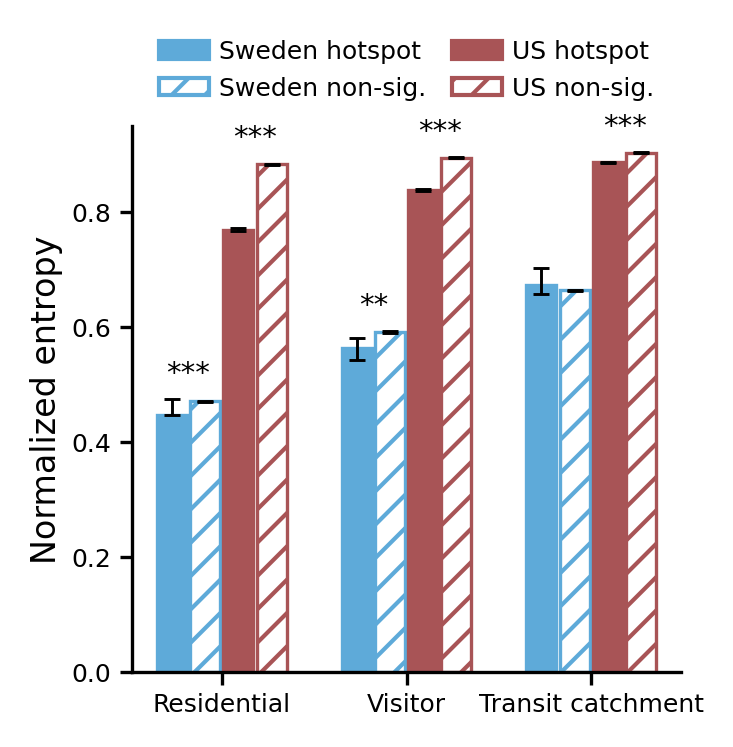

In [98]:
# Figure 7d: Diversity Characterization of Hotspots (Pooled by Country)
# Compare residential, visitor, and transit catchment diversity
# between hotspots and non-significant POIs

analysis_df['country'] = analysis_df['city'].apply(lambda x: 'Sweden' if x.startswith('Sweden') else 'US')

diversity_cols = {
    'Residential': 'residential_entropy_birth_norm',
    'Visitor': 'visitor_entropy_birth_norm',
    'Transit catchment': 'catchment_entropy_birth_norm',
}

results_all = []
mw_results_all = {}

for div_label, div_col in diversity_cols.items():
    for country in ['Sweden', 'US']:
        country_df = analysis_df[analysis_df['country'] == country]

        hotspot_vals = country_df[country_df['group'] == 'Hotspot'][div_col].dropna()
        nonsig_vals = country_df[country_df['group'] == 'Non-significant'][div_col].dropna()

        # Mann-Whitney U test
        if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
            stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        else:
            stat, pval = np.nan, 1.0
        mw_results_all[(div_label, country)] = {'stat': stat, 'pval': pval,
                                                 'n_hotspot': len(hotspot_vals),
                                                 'n_nonsig': len(nonsig_vals)}

        for group in ['Hotspot', 'Non-significant']:
            subset = country_df[country_df['group'] == group][div_col].dropna()
            if len(subset) > 0:
                median, lower, upper = bootstrap_median_ci(subset)
            else:
                median, lower, upper = np.nan, np.nan, np.nan
            results_all.append({
                'diversity': div_label,
                'country': country,
                'group': group,
                'median': median,
                'lower': lower,
                'upper': upper,
            })

results_df = pd.DataFrame(results_all)

# Print results
print("Mann-Whitney U Tests: Hotspot vs Non-significant (Pooled by Country)")
print("=" * 80)
print(f"{'Diversity':<20} {'Country':<10} {'U':>12} {'p-value':>12} {'Sig':>5} {'n_hot':>8} {'n_ns':>8}")
print("-" * 80)
for div_label in diversity_cols:
    for country in ['Sweden', 'US']:
        r = mw_results_all[(div_label, country)]
        pval = r['pval']
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"{div_label:<20} {country:<10} {r['stat']:>12.0f} {pval:>12.4f} {sig:>5} {r['n_hotspot']:>8} {r['n_nonsig']:>8}")

# Plot: x = diversity type, y = median, color = country, fill = hotspot status
fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(60)), dpi=300)

div_labels = list(diversity_cols.keys())
x_positions = np.arange(len(div_labels))

# Offsets: country x group
bar_width = 0.18
country_colors = {'Sweden': COLORS['Sweden'], 'US': COLORS['US']}
bar_offsets = {
    ('Sweden', 'Hotspot'): -1.5 * bar_width,
    ('Sweden', 'Non-significant'): -0.5 * bar_width,
    ('US', 'Hotspot'): 0.5 * bar_width,
    ('US', 'Non-significant'): 1.5 * bar_width,
}

for country in ['Sweden', 'US']:
    for group in ['Hotspot', 'Non-significant']:
        subset = results_df[(results_df['country'] == country) & (results_df['group'] == group)]
        x_pos = x_positions + bar_offsets[(country, group)]

        medians = [subset[subset['diversity'] == d]['median'].values[0] for d in div_labels]
        lowers = [subset[subset['diversity'] == d]['lower'].values[0] for d in div_labels]
        uppers = [subset[subset['diversity'] == d]['upper'].values[0] for d in div_labels]

        yerr_lower = [m - l for m, l in zip(medians, lowers)]
        yerr_upper = [u - m for m, u in zip(medians, uppers)]

        facecolor = country_colors[country] if group == 'Hotspot' else 'white'
        hatch = None if group == 'Hotspot' else '///'
        ax.bar(
            x_pos,
            medians,
            width=bar_width * 0.9,
            yerr=[yerr_lower, yerr_upper],
            color=facecolor,
            edgecolor=country_colors[country],
            linewidth=0.8,
            hatch=hatch,
            capsize=2,
            error_kw={'elinewidth': 0.7, 'capthick': 0.7, 'ecolor': 'black'},
            label=f"{country} - {group}",
        )

# Add significance markers
for j, div_label in enumerate(div_labels):
    for country in ['Sweden', 'US']:
        pval = mw_results_all[(div_label, country)]['pval']
        if pval < 0.05:
            country_midpoint = np.mean([
                bar_offsets[(country, 'Hotspot')],
                bar_offsets[(country, 'Non-significant')],
            ])
            # Get max y for this group
            sub = results_df[(results_df['diversity'] == div_label) & (results_df['country'] == country)]
            y_max = sub['upper'].max() + 0.02
            sig_text = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            ax.text(j + country_midpoint, y_max, sig_text, va='bottom', ha='center', fontsize=7)

ax.set_xticks(x_positions)
ax.set_xticklabels(div_labels)
ax.set_ylabel('Normalized entropy')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['Sweden'], edgecolor=COLORS['Sweden'], label='Sweden hotspot'),
    Patch(facecolor='white', edgecolor=COLORS['Sweden'], hatch='///', label='Sweden non-sig.'),
    Patch(facecolor=COLORS['US'], edgecolor=COLORS['US'], label='US hotspot'),
    Patch(facecolor='white', edgecolor=COLORS['US'], hatch='///', label='US non-sig.'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.2),
          ncol=2, frameon=False, fontsize=6, handletextpad=0.4, columnspacing=1.0)

#plt.tight_layout(rect=[0, 0, 1, 0.82])
save_figure(fig, 'fig7d_diversity_hotspot_characterization')
plt.show()


In [43]:
# Logistic Regression BY COUNTRY
# Fixed effects: distance to center, POI density, transit proximity
# NO category random effects - simple pooled logit by country
# Uses birth_background_all results
# Sweden is pooled across all available Swedish cities, not only the six Figure 7 cities

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix


def logit_city_key(city):
    """Normalize coefficient and POI city labels for merging."""
    city = str(city)
    if city.startswith('Sweden - '):
        return city.replace('Sweden - ', '', 1)
    if city.startswith('US - '):
        return city.replace('US - ', '', 1)
    return city


# Rebuild the logit input from all birth_background_all coefficient rows.
# The Figure 7 analysis_df is intentionally restricted to six mapped cities; for
# the country-level logit, pool all Swedish cities to avoid too few hotspots.
coef_birth_logit = coef_df[
    (coef_df['entropy_type'] == 'birth') &
    (coef_df['venue_category'] == 'all') &
    (
        coef_df['city'].astype(str).str.startswith('Sweden - ') |
        coef_df['city'].isin(['US - new_york', 'US - washington_dc', 'US - atlanta'])
    )
].copy()

coef_birth_logit['poi_id_str'] = coef_birth_logit['poi_id'].astype(str)
coef_birth_logit['city_key'] = coef_birth_logit['city'].apply(logit_city_key)
coef_birth_logit['country'] = np.where(
    coef_birth_logit['city'].astype(str).str.startswith('US - '),
    'US',
    'Sweden'
)

all_pois_logit = all_pois.copy()
all_pois_logit['poi_id_str'] = all_pois_logit['poi_id'].astype(str)
all_pois_logit['city_key'] = all_pois_logit['city'].apply(logit_city_key)

# Fixed effect predictors
fixed_cols = [
    'dist_to_center_km',
    'poi_density_500m',
    'dist_to_transit_m',
]

merge_cols = ['poi_id_str', 'city_key'] + fixed_cols
logit_df = coef_birth_logit.merge(
    all_pois_logit[merge_cols].drop_duplicates(subset=['poi_id_str', 'city_key']),
    on=['poi_id_str', 'city_key'],
    how='left',
)

logit_df['group'] = logit_df.apply(
    lambda r: 'Hotspot' if r['is_hotspot'] else ('Coldspot' if r['is_coldspot'] else 'Non-significant'),
    axis=1
)
logit_df = logit_df[logit_df['group'].isin(['Hotspot', 'Non-significant'])].copy()
logit_df['is_hotspot_binary'] = (logit_df['group'] == 'Hotspot').astype(int)

# Clean data
logit_clean = logit_df[['is_hotspot_binary', 'country', 'city'] + fixed_cols].copy()
for col in fixed_cols:
    logit_clean[col] = pd.to_numeric(logit_clean[col], errors='coerce')
logit_clean = logit_clean.dropna()

print("=" * 80)
print("LOGISTIC REGRESSION BY COUNTRY")
print("Predictors: distance to center, POI density, transit proximity")
print("Data source: birth_background_all (pooled across all venue categories)")
print("Sweden sample: all available Swedish cities pooled")
print("US sample: New York, Washington DC, Atlanta")
print("=" * 80)
print("\nCountry/city sample sizes after cleaning:")
print(logit_clean.groupby(['country', 'city'])['is_hotspot_binary'].agg(['count', 'sum']))

results_by_country = {}

for country in ['Sweden', 'US']:
    print(f"\n{'='*70}")
    print(f"{country}")
    print('='*70)

    country_df = logit_clean[logit_clean['country'] == country].copy()

    if country_df['is_hotspot_binary'].nunique() < 2:
        raise ValueError(f"Cannot fit {country} logit: outcome has only one class.")

    # Standardize numeric predictors
    means = {}
    stds = {}
    for col in fixed_cols:
        means[col] = country_df[col].mean()
        stds[col] = country_df[col].std()
        if stds[col] == 0 or np.isnan(stds[col]):
            raise ValueError(f"Cannot standardize {col} for {country}: zero or missing SD.")
        country_df[col] = (country_df[col] - means[col]) / stds[col]

    y = country_df['is_hotspot_binary'].values.astype(float)
    X = sm.add_constant(country_df[fixed_cols].values.astype(float))

    print(f"Sample size: {len(country_df):,}")
    print(f"Cities: {country_df['city'].nunique():,}")
    print(f"Hotspots: {int(y.sum()):,} ({100*y.mean():.1f}%)")

    # Fit logistic regression
    print("\nFitting logistic regression...")
    model = Logit(y, X)
    result = model.fit(disp=0)

    # Fixed effects
    fixed_names = ['const'] + fixed_cols
    print(f"\nCOEFFICIENTS (standardized, 1 unit = 1 SD):")
    print("-" * 60)
    
    coefs = result.params
    ses = result.bse
    pvals = result.pvalues
    
    fixed_summary = pd.DataFrame({
        'Variable': fixed_names,
        'Coef': coefs,
        'Std Err': ses,
        'z': result.tvalues,
        'P>|z|': pvals,
        'Odds Ratio': np.exp(coefs),
        'OR 95% CI': [f"[{np.exp(m-1.96*s):.3f}, {np.exp(m+1.96*s):.3f}]"
                      for m, s in zip(coefs, ses)],
    }).set_index('Variable')
    print(fixed_summary.to_string())

    # Performance metrics
    y_pred_prob = result.predict(X)
    y_pred = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y, y_pred_prob)
    acc = accuracy_score(y, y_pred)

    print(f"\nMODEL PERFORMANCE:")
    print("-" * 60)
    print(f"  Pseudo R-squared: {result.prsquared:.4f}")
    print(f"  Log-Likelihood: {result.llf:.1f}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Accuracy: {acc:.4f}")

    tn, fp, fn, tp = confusion_matrix(y.astype(int), y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"  Sensitivity (TPR): {sensitivity:.3f}")
    print(f"  Specificity (TNR): {specificity:.3f}")

    # Interpretation
    print(f"\nINTERPRETATION:")
    print("-" * 60)
    for i, var in enumerate(fixed_cols):
        coef = coefs[i+1]
        se = ses[i+1]
        pval = pvals[i+1]
        or_val = np.exp(coef)
        ci_low = np.exp(coef - 1.96*se)
        ci_high = np.exp(coef + 1.96*se)
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        direction = "increases" if or_val > 1 else "decreases"
        pct = abs(or_val - 1) * 100
        print(f"  {var}: OR={or_val:.3f} [{ci_low:.3f}, {ci_high:.3f}] (1 SD {direction} odds by {pct:.1f}%) {sig}")

    results_by_country[country] = {
        'n': len(country_df),
        'n_cities': country_df['city'].nunique(),
        'hotspot_pct': 100*y.mean(),
        'pseudo_r2': result.prsquared,
        'auc': auc,
        'accuracy': acc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'fixed_summary': fixed_summary,
    }

# Comparison summary
print("\n" + "=" * 80)
print("COUNTRY COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Metric':<25} {'Sweden':>15} {'US':>15}")
print("-" * 55)
print(f"{'Sample size':<25} {results_by_country['Sweden']['n']:>15,} {results_by_country['US']['n']:>15,}")
print(f"{'Cities':<25} {results_by_country['Sweden']['n_cities']:>15,} {results_by_country['US']['n_cities']:>15,}")
print(f"{'Hotspot %':<25} {results_by_country['Sweden']['hotspot_pct']:>15.1f} {results_by_country['US']['hotspot_pct']:>15.1f}")
print(f"{'Pseudo R-squared':<25} {results_by_country['Sweden']['pseudo_r2']:>15.4f} {results_by_country['US']['pseudo_r2']:>15.4f}")
print(f"{'ROC-AUC':<25} {results_by_country['Sweden']['auc']:>15.4f} {results_by_country['US']['auc']:>15.4f}")
print(f"{'Accuracy':<25} {results_by_country['Sweden']['accuracy']:>15.4f} {results_by_country['US']['accuracy']:>15.4f}")
print(f"{'Sensitivity':<25} {results_by_country['Sweden']['sensitivity']:>15.4f} {results_by_country['US']['sensitivity']:>15.4f}")
print(f"{'Specificity':<25} {results_by_country['Sweden']['specificity']:>15.4f} {results_by_country['US']['specificity']:>15.4f}")

print("\nODDS RATIOS COMPARISON:")
print(f"{'Predictor':<25} {'Sweden':>12} {'US':>12}")
print("-" * 50)
for pred in fixed_cols:
    se_or = results_by_country['Sweden']['fixed_summary'].loc[pred, 'Odds Ratio']
    us_or = results_by_country['US']['fixed_summary'].loc[pred, 'Odds Ratio']
    print(f"{pred:<25} {se_or:>12.3f} {us_or:>12.3f}")



LOGISTIC REGRESSION BY COUNTRY
Predictors: distance to center, POI density, transit proximity
Data source: birth_background_all (pooled across all venue categories)
Sweden sample: all available Swedish cities pooled
US sample: New York, Washington DC, Atlanta

Country/city sample sizes after cleaning:
                               count    sum
country city                               
Sweden  Sweden - Göteborg      16616    126
        Sweden - Helsingborg    4812    323
        Sweden - Linköping      5308     54
        Sweden - Lund           4822      5
        Sweden - Malmö         12475     39
        Sweden - Stockholm     35413    173
        Sweden - Uppsala        7728     21
        Sweden - Västerås       5201     89
        Sweden - Örebro         5407     52
US      US - atlanta           33837   4168
        US - new_york         136384  48162
        US - washington_dc     24091   1842

Sweden
Sample size: 97,782
Cities: 9
Hotspots: 882 (0.9%)

Fitting logistic regr

Logistic regression odds ratios
country          variable       or   ci_low   ci_high          pval
 Sweden dist_to_center_km 0.110767 0.081008  0.151458  3.197853e-43
 Sweden  poi_density_500m 0.704886 0.646299  0.768785  2.807285e-15
 Sweden dist_to_transit_m 3.934393 0.296907 52.135638  2.988316e-01
     US dist_to_center_km 1.171191 1.157985  1.184547 2.958910e-164
     US  poi_density_500m 0.956293 0.945220  0.967495  5.412293e-14
     US dist_to_transit_m 1.300922 1.284225  1.317837  0.000000e+00
Saved: outputs/figures/fig7g_logit_odds_ratios.pdf
Saved: outputs/figures/fig7g_logit_odds_ratios.png


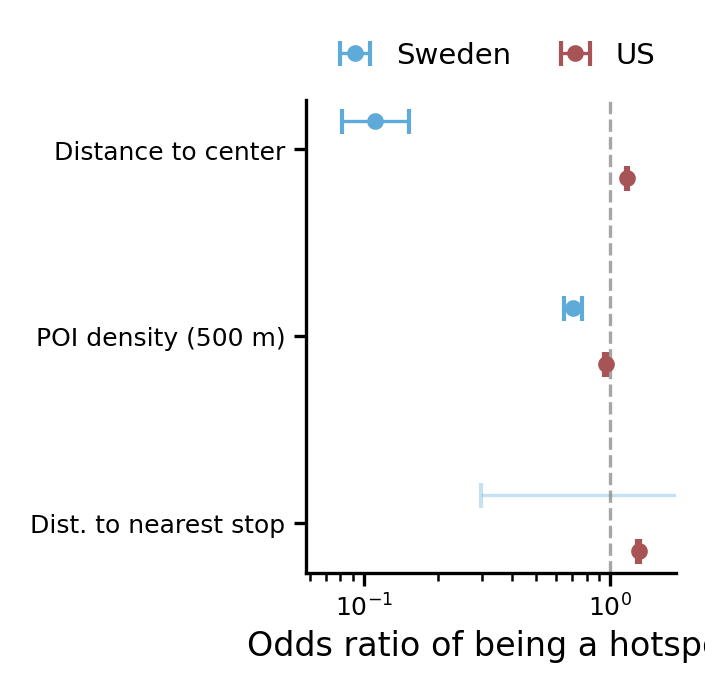

In [90]:
# Figure 7g: Logistic Regression Odds Ratios
# Predictors of transit-mixing hotspot membership by country
# Odds ratios are easier to interpret than logit coefficients: OR > 1 means higher odds

logit_plot_rows = []

LOGIT_VAR_LABELS = {
    'dist_to_center_km': 'Distance to center',
    'poi_density_500m': 'POI density (500 m)',
    'dist_to_transit_m': 'Dist. to nearest stop',
}

for country in ['Sweden', 'US']:
    fixed_summary = results_by_country[country]['fixed_summary']
    for var in fixed_cols:
        coef = fixed_summary.loc[var, 'Coef']
        se = fixed_summary.loc[var, 'Std Err']
        pval = fixed_summary.loc[var, 'P>|z|']
        or_val = np.exp(coef)
        ci_low = np.exp(coef - 1.96 * se)
        ci_high = np.exp(coef + 1.96 * se)

        logit_plot_rows.append({
            'country': country,
            'variable': var,
            'label': LOGIT_VAR_LABELS[var],
            'or': or_val,
            'ci_low': ci_low,
            'ci_high': ci_high,
            'pval': pval,
        })

logit_or_df = pd.DataFrame(logit_plot_rows)

print("Logistic regression odds ratios")
print("=" * 60)
print(logit_or_df[['country', 'variable', 'or', 'ci_low', 'ci_high', 'pval']].to_string(index=False))

fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(60)), dpi=300)

variables = fixed_cols
y_positions = np.arange(len(variables))
offset = 0.15
country_order = ['Sweden', 'US']
country_labels = {'Sweden': 'Sweden', 'US': 'US'}
country_colors = {'Sweden': COLORS['Sweden'], 'US': COLORS['US']}

for i, country in enumerate(country_order):
    country_data = logit_or_df[logit_or_df['country'] == country].set_index('variable')
    y_pos = y_positions + (i - 0.5) * offset * 2

    odds = np.array([country_data.loc[var, 'or'] for var in variables])
    ci_low = np.array([country_data.loc[var, 'ci_low'] for var in variables])
    ci_high = np.array([country_data.loc[var, 'ci_high'] for var in variables])
    pvals = np.array([country_data.loc[var, 'pval'] for var in variables])

    xerr = np.vstack([odds - ci_low, ci_high - odds])

    for j, var in enumerate(variables):
        alpha = 1.0 if pvals[j] < 0.05 else 0.35
        ax.errorbar(
            odds[j],
            y_pos[j],
            xerr=[[xerr[0, j]], [xerr[1, j]]],
            fmt='o',
            color=country_colors[country],
            capsize=3,
            markersize=3,
            alpha=alpha,
            label=country_labels[country] if j == 0 else None,
        )

ax.axvline(x=1, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_xscale('log')

# Set the x-axis range from the interpretable estimates, excluding Sweden's
# non-significant transit-proximity coefficient with its very wide interval.
xlim_source = logit_or_df[~(
    (logit_or_df['country'] == 'Sweden') &
    (logit_or_df['variable'] == 'dist_to_transit_m')
)].copy()
xmin = xlim_source['ci_low'].min()
xmax = xlim_source['ci_high'].max()
log_xmin = np.log10(xmin)
log_xmax = np.log10(xmax)
pad = 0.12 * (log_xmax - log_xmin)
ax.set_xlim(10 ** (log_xmin - pad), 10 ** (log_xmax + pad))

ax.set_yticks(y_positions)
ax.set_yticklabels([LOGIT_VAR_LABELS[var] for var in variables])
ax.invert_yaxis()
ax.set_xlabel('Odds ratio of being a hotspot')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, handletextpad=0.4, columnspacing=1.2)

plt.tight_layout()
save_figure(fig, 'fig7g_logit_odds_ratios')
plt.show()



In [44]:
# Table: Logistic Regression Results (Manuscript Format)
# Predicting Hotspot Status by Country

print("=" * 90)
print("TABLE: Logistic Regression Predicting Transit-Mixing Hotspots")
print("=" * 90)

var_labels = {
    'dist_to_center_km': 'Distance to center (km)',
    'poi_density_500m': 'POI density (500m)',
    'dist_to_transit_m': 'Transit proximity (m)',
}

# Build LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Logistic Regression Predicting Transit-Mixing Hotspots}")
latex_lines.append(r"\label{tab:logit_hotspot}")
latex_lines.append(r"\small")
latex_lines.append(r"\begin{tabular}{lcccc}")
latex_lines.append(r"\toprule")
latex_lines.append(r" & \multicolumn{2}{c}{Sweden} & \multicolumn{2}{c}{United States} \\")
latex_lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
latex_lines.append(r"Variable & OR [95\% CI] & & OR [95\% CI] & \\")
latex_lines.append(r"\midrule")

for var in fixed_cols:
    label = var_labels.get(var, var)

    # Sweden
    se_coef = results_by_country['Sweden']['fixed_summary'].loc[var, 'Coef']
    se_se = results_by_country['Sweden']['fixed_summary'].loc[var, 'Std Err']
    se_or = results_by_country['Sweden']['fixed_summary'].loc[var, 'Odds Ratio']
    se_pval = results_by_country['Sweden']['fixed_summary'].loc[var, 'P>|z|']
    se_ci_low = np.exp(se_coef - 1.96 * se_se)
    se_ci_high = np.exp(se_coef + 1.96 * se_se)
    se_sig = '***' if se_pval < 0.001 else '**' if se_pval < 0.01 else '*' if se_pval < 0.05 else ''

    # US
    us_coef = results_by_country['US']['fixed_summary'].loc[var, 'Coef']
    us_se = results_by_country['US']['fixed_summary'].loc[var, 'Std Err']
    us_or = results_by_country['US']['fixed_summary'].loc[var, 'Odds Ratio']
    us_pval = results_by_country['US']['fixed_summary'].loc[var, 'P>|z|']
    us_ci_low = np.exp(us_coef - 1.96 * us_se)
    us_ci_high = np.exp(us_coef + 1.96 * us_se)
    us_sig = '***' if us_pval < 0.001 else '**' if us_pval < 0.01 else '*' if us_pval < 0.05 else ''

    latex_lines.append(f"\quad {label} & {se_or:.3f} [{se_ci_low:.3f}, {se_ci_high:.3f}]{se_sig} & & {us_or:.3f} [{us_ci_low:.3f}, {us_ci_high:.3f}]{us_sig} & \\\\")

latex_lines.append(r"\addlinespace[3pt]")

# Model fit
latex_lines.append(r"\textit{Model Performance} & & & & \\")
latex_lines.append(f"\quad Pseudo $R^2$ & {results_by_country['Sweden']['pseudo_r2']:.3f} & & {results_by_country['US']['pseudo_r2']:.3f} & \\\\")
latex_lines.append(f"\quad ROC-AUC & {results_by_country['Sweden']['auc']:.3f} & & {results_by_country['US']['auc']:.3f} & \\\\")
latex_lines.append(f"\quad Accuracy & {results_by_country['Sweden']['accuracy']:.3f} & & {results_by_country['US']['accuracy']:.3f} & \\\\")
latex_lines.append(f"\quad Sensitivity & {results_by_country['Sweden']['sensitivity']:.3f} & & {results_by_country['US']['sensitivity']:.3f} & \\\\")
latex_lines.append(f"\quad Specificity & {results_by_country['Sweden']['specificity']:.3f} & & {results_by_country['US']['specificity']:.3f} & \\\\")

latex_lines.append(r"\addlinespace[3pt]")
latex_lines.append(f"\quad N & {results_by_country['Sweden']['n']:,} & & {results_by_country['US']['n']:,} & \\\\")
latex_lines.append(f"\quad Hotspots (\%) & {results_by_country['Sweden']['hotspot_pct']:.1f} & & {results_by_country['US']['hotspot_pct']:.1f} & \\\\")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\begin{tablenotes}")
latex_lines.append(r"\small")
latex_lines.append(r"\item Note: Odds ratios (OR) with 95\% confidence intervals. Predictors are standardized (1 unit = 1 SD).")
latex_lines.append(r"\item * p<0.05, ** p<0.01, *** p<0.001.")
latex_lines.append(r"\item Data source: birth\_background\_all GWR results (all POIs pooled).")
latex_lines.append(r"\end{tablenotes}")
latex_lines.append(r"\end{table}")

# Print LaTeX
print("\nLaTeX Table:")
print("-" * 90)
for line in latex_lines:
    print(line)

# Save to file
with open('outputs/tables/logit_hotspot_results.tex', 'w') as f:
    f.write('\n'.join(latex_lines))
print("\nSaved: outputs/tables/logit_hotspot_results.tex")

# Also save text version
with open('outputs/tables/logit_hotspot_results.txt', 'w') as f:
    f.write("LOGISTIC REGRESSION: PREDICTING TRANSIT-MIXING HOTSPOTS\n")
    f.write("=" * 70 + "\n\n")
    f.write("Data: birth_background_all (all POIs pooled, no category stratification)\n\n")
    for country in ['Sweden', 'US']:
        f.write(f"{country}:\n")
        f.write(results_by_country[country]['fixed_summary'].to_string())
        f.write(f"\n\nPseudo R-squared: {results_by_country[country]['pseudo_r2']:.4f}")
        f.write(f"\nROC-AUC: {results_by_country[country]['auc']:.4f}")
        f.write(f"\nAccuracy: {results_by_country[country]['accuracy']:.4f}\n\n")
print("Saved: outputs/tables/logit_hotspot_results.txt")

TABLE: Logistic Regression Predicting Transit-Mixing Hotspots

LaTeX Table:
------------------------------------------------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Logistic Regression Predicting Transit-Mixing Hotspots}
\label{tab:logit_hotspot}
\small
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{Sweden} & \multicolumn{2}{c}{United States} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
Variable & OR [95\% CI] & & OR [95\% CI] & \\
\midrule
\quad Distance to center (km) & 0.111 [0.081, 0.151]*** & & 1.171 [1.158, 1.185]*** & \\
\quad POI density (500m) & 0.705 [0.646, 0.769]*** & & 0.956 [0.945, 0.967]*** & \\
\quad Transit proximity (m) & 3.934 [0.297, 52.136] & & 1.301 [1.284, 1.318]*** & \\
\addlinespace[3pt]
\textit{Model Performance} & & & & \\
\quad Pseudo $R^2$ & 0.026 & & 0.023 & \\
\quad ROC-AUC & 0.673 & & 0.582 & \\
\quad Accuracy & 0.991 & & 0.721 & \\
\quad Sensitivity & 0.000 & & 0.044 & \\
\quad Specificity & 1.000 & & 0.983 &